# Experiment: 06 CASALS L1B Raw Waveform Noise and Peak Diagnostics

Objective:

- Read CASALS L1B H5 `rx_waveform` records directly.
- Estimate background level and random-noise scale from raw waveform samples and H5 background metadata when available.
- Detect peaks on the **raw background-corrected waveform only**. No Savitzky-Golay smoothing, no moving-average smoothing, and no smoothed waveform is used for feature computation.
- Compute diagnostic features such as peak dominance, peak ratio, prominence, width, area, peak separation, and waveform ambiguity.
- Add a 10 m one-way range scale bar on representative raw-waveform figures when the RX bin time interval can be read from the H5 file or supplied manually.
- Optionally join these waveform diagnostics with an existing classified LAS/LAZ product from `classify_and_evaluate_casals_refh.py` or `transfer_3dep_labels_to_casals.py`.
- Inspect whether raw waveform features help explain errors such as pseudo-reference noise predicted as processed.

Scientific boundary:

The H5 file provides an official geolocated `refh` point per pulse. The secondary waveform peaks extracted here are diagnostic only. They are not treated as official georeferenced returns. Peak-ratio features are interpreted as peak dominance / waveform ambiguity, not as a direct noise probability.


## Method overview

This notebook separates waveform analysis into four levels.

1. **Background and random noise**: estimate a baseline and noise scale from H5 fields (`bg_mean`, `bg_std`) when available and from robust empirical statistics otherwise.
2. **Peak detection**: detect peaks after background correction using height and prominence thresholds expressed in units of the estimated noise scale.
3. **Component diagnostics**: compute top-peak amplitude, prominence, width, area, number of peaks, peak separation, and peak-ratio features.
4. **Evaluation linkage**: if a classified LAZ is supplied, join waveform diagnostics to LAS points using `point_index` or `pulse_index`, then compare waveform statistics across predicted classes and pseudo-reference error groups.

The key design choice is conservative: peak-ratio features are treated as **waveform ambiguity / dominance diagnostics**, not as direct noise labels.

In [1]:
from __future__ import annotations

import json
import math
import re
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Iterable, Optional, Sequence

import h5py
import laspy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from scipy.signal import find_peaks, peak_widths
from scipy.stats import kurtosis, skew


## Configuration

Path defaults follow the existing `CASALS_L1B/notebooks` layout. Adjust the explicit path overrides if your notebook is run from a different working directory.

In [2]:
# --------------------------------------------------------------------------------------
# Paths
# --------------------------------------------------------------------------------------
PROJECT_ROOT = Path("..").resolve()
H5_ROOT = PROJECT_ROOT / "casals_h5_downloads"
CLASSIFIED_LAZ_ROOTS = [
    PROJECT_ROOT / "outputs" / "classify_and_evaluate_casals_refh",
    PROJECT_ROOT / "outputs" / "transfer_3dep_labels_to_casals",
    PROJECT_ROOT / "outputs" / "extract_refh_ground" / "point_clouds",
]
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "waveform_noise_raw_diagnostics"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Set these to explicit files if automatic discovery is not desired.
H5_PATH_OVERRIDE: str | None = None
CLASSIFIED_LAZ_PATH_OVERRIDE: str | None = None

# If no classified LAZ is used, sample directly from H5.
USE_CLASSIFIED_LAZ_IF_AVAILABLE = True
H5_STEM_HINT = "casals_l1b_20241112T165718_001_02"  # used only for discovery

# --------------------------------------------------------------------------------------
# Sampling
# --------------------------------------------------------------------------------------
RANDOM_SEED = 42
MAX_WAVEFORM_ROWS = 6000             # total waveforms to analyze in batch
SAMPLES_PER_CLASS = 1200             # used when classified LAZ is available
SAMPLES_PER_ERROR_GROUP = 1200       # used when eval_gt_class is available
CHUNK_SIZE_LAS = 1_000_000
H5_READ_CHUNK_ROWS = 512             # number of waveform rows read per H5 slice operation

# --------------------------------------------------------------------------------------
# Waveform background/noise estimation
# --------------------------------------------------------------------------------------
BACKGROUND_METHOD = "prefer_h5_then_edges"  # options: prefer_h5_then_edges, edges, lower_quantile
EDGE_BACKGROUND_BINS = 256                  # first/last bins used by empirical edge estimate
LOWER_QUANTILE_FOR_BACKGROUND = 40.0         # robust fallback; uses values <= this percentile
MIN_NOISE_STD = 1e-6

# --------------------------------------------------------------------------------------
# Raw peak detection
# --------------------------------------------------------------------------------------
# Peak detection is intentionally performed on raw background-corrected waveform samples.
# No smoothed waveform is computed or used.
PEAK_HEIGHT_MIN_SIGMA = 4.0
PEAK_PROMINENCE_MIN_SIGMA = 3.0
PEAK_MIN_DISTANCE_BINS = 6
PEAK_MIN_WIDTH_BINS = 1.0
PEAK_SORT_KEY = "amp_bgcorr"  # options: amp_bgcorr, prominence
TOP_K_PEAKS_TO_STORE = 5

# --------------------------------------------------------------------------------------
# RX-bin time interval and range scale bar
# --------------------------------------------------------------------------------------
# RX_BIN_TIME_INTERVAL_S_OVERRIDE is the safest option if the H5 file does not expose
# an unambiguous RX waveform bin/sample interval. Unit: seconds per waveform bin.
RX_BIN_TIME_INTERVAL_S_OVERRIDE: float | None = None

# One-way range distance represented by the scale bar.
SCALE_BAR_RANGE_M = 10.0
SHOW_10M_SCALE_BAR = True
SHOW_SECONDARY_RANGE_AXIS = False

# Light propagation settings. For air, n≈1.00027; the difference is tiny at this scale.
C_LIGHT_M_PER_S = 299_792_458.0
AIR_REFRACTIVE_INDEX = 1.00027

# --------------------------------------------------------------------------------------
# Visualization and outputs
# --------------------------------------------------------------------------------------
N_REPRESENTATIVE_WAVEFORMS = 24
SAVE_FEATURE_CSV = True
SAVE_SUMMARY_CSV = True
FIG_DPI = 150

CLASS_NAME_MAP = {
    1: "processed_unclassified",
    2: "ground",
    7: "noise",
    18: "high_noise",
}


## H5 and LAS discovery helpers

The H5 dataset names in CASALS files may vary slightly across versions. The helper functions below search both exact paths and dataset basenames.

In [3]:
def list_h5_datasets(h5: h5py.File) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    def visitor(name: str, obj: Any) -> None:
        if isinstance(obj, h5py.Dataset):
            rows.append({
                "path": name,
                "basename": Path(name).name,
                "shape": tuple(obj.shape),
                "ndim": int(obj.ndim),
                "dtype": str(obj.dtype),
            })

    h5.visititems(visitor)
    return pd.DataFrame(rows).sort_values("path").reset_index(drop=True)


def find_h5_dataset_path(h5: h5py.File, candidates: Sequence[str], required: bool = True) -> str | None:
    candidate_set = {str(v).strip("/") for v in candidates}
    for name in candidate_set:
        if name in h5 and isinstance(h5[name], h5py.Dataset):
            return name

    datasets = list_h5_datasets(h5)
    if datasets.empty:
        if required:
            raise KeyError("H5 file contains no datasets.")
        return None

    lower_candidates = {v.lower() for v in candidate_set}
    basename_hits = datasets[datasets["basename"].str.lower().isin(lower_candidates)]
    if not basename_hits.empty:
        return str(basename_hits.iloc[0]["path"])

    path_hits = datasets[datasets["path"].str.lower().isin(lower_candidates)]
    if not path_hits.empty:
        return str(path_hits.iloc[0]["path"])

    if required:
        raise KeyError(f"Could not locate any H5 dataset from candidates: {list(candidates)}")
    return None


def read_optional_h5_vector(h5: h5py.File, candidates: Sequence[str], n_expected: int | None = None) -> tuple[np.ndarray | None, str | None]:
    path = find_h5_dataset_path(h5, candidates, required=False)
    if path is None:
        return None, None
    arr = np.asarray(h5[path][...]).reshape(-1)
    if n_expected is not None and arr.size != n_expected:
        warnings.warn(f"Optional H5 dataset {path} has size {arr.size}, expected {n_expected}; ignoring it.")
        return None, path
    return arr, path


def normalize_time_interval_seconds(value: float, source: str) -> float:
    """Convert a scalar time interval to seconds using source-name hints and safe heuristics.

    The preferred case is an H5 dataset/attribute name that explicitly carries units
    such as ns/us/ms/s. If no unit is given, values in the typical ns numeric range
    (0.01 to 1000) are interpreted as nanoseconds; very small values are interpreted
    as seconds. Ambiguous or non-positive values return NaN.
    """
    try:
        val = float(np.asarray(value).reshape(-1)[0])
    except Exception:
        return float("nan")
    if not np.isfinite(val) or val <= 0.0:
        return float("nan")

    text = str(source).lower()
    if any(token in text for token in ["nanosecond", "_ns", "(ns)", "[ns]", " ns"]):
        return val * 1e-9
    if any(token in text for token in ["microsecond", "_us", "(us)", "[us]", " us", "_µs"]):
        return val * 1e-6
    if any(token in text for token in ["millisecond", "_ms", "(ms)", "[ms]", " ms"]):
        return val * 1e-3
    if any(token in text for token in ["second", "_s", "(s)", "[s]", " sec", "seconds"]):
        return val

    # Conservative heuristic for common H5 cases.
    # RX waveform bin intervals are usually much smaller than 1 microsecond.
    if 1e-12 <= val <= 1e-3:
        return val
    if 0.01 <= val <= 1000.0:
        return val * 1e-9
    return float("nan")


def iter_numeric_scalar_attrs(h5: h5py.File) -> list[dict[str, Any]]:
    rows: list[dict[str, Any]] = []

    def collect_attrs(obj_path: str, obj: Any) -> None:
        for key, value in obj.attrs.items():
            arr = np.asarray(value)
            if arr.size != 1:
                continue
            try:
                scalar = float(arr.reshape(-1)[0])
            except Exception:
                continue
            if np.isfinite(scalar):
                rows.append({
                    "object_path": "/" if obj_path == "" else obj_path,
                    "attr_name": str(key),
                    "value": scalar,
                    "source": f"attr:{'/' if obj_path == '' else obj_path}:{key}",
                })

    collect_attrs("", h5)
    h5.visititems(collect_attrs)
    return rows


def find_dataset_path_soft(h5: h5py.File, candidates: Sequence[str]) -> str | None:
    try:
        return find_h5_dataset_path(h5, candidates, required=False)
    except Exception:
        return None


def infer_rx_bin_time_interval_s(
    h5: h5py.File,
    rx_dataset_path: str,
    n_bins: int,
    override_s: float | None = None,
) -> dict[str, Any]:
    """Infer RX waveform bin/sample interval in seconds.

    This function deliberately avoids using pulse-level `delta_time` as the waveform
    bin interval. It searches only RX/sample/bin/waveform interval names and attributes.
    If the result is ambiguous, set RX_BIN_TIME_INTERVAL_S_OVERRIDE explicitly.
    """
    candidate_rows: list[dict[str, Any]] = []

    if override_s is not None:
        dt_s = normalize_time_interval_seconds(float(override_s), "manual_override_seconds")
        return {
            "rx_bin_time_interval_s": dt_s,
            "source": "manual_override_seconds",
            "status": "ok" if np.isfinite(dt_s) else "invalid_override",
            "candidate_table": pd.DataFrame(),
        }

    scalar_dataset_candidates = [
        "rx_bin_time_interval", "rx_sample_interval", "rx_sampling_interval",
        "rx_sample_period", "rx_dt", "rx_delta_t", "rx_waveform_dt",
        "rx_waveform_sample_interval", "rx_waveform_sampling_interval",
        "waveform_sample_interval", "waveform_sampling_interval",
        "bin_time_interval", "sample_interval", "sampling_interval",
    ]
    coordinate_dataset_candidates = [
        "rx_time", "rx_times", "rx_bin_time", "rx_bin_times",
        "rx_waveform_time", "rx_waveform_times", "waveform_time",
        "waveform_times", "sample_time", "sample_times",
    ]

    for candidates, mode in [
        (scalar_dataset_candidates, "scalar_dataset"),
        (coordinate_dataset_candidates, "coordinate_dataset"),
    ]:
        path = find_dataset_path_soft(h5, candidates)
        if path is None:
            continue
        arr = np.asarray(h5[path][...], dtype=np.float64).reshape(-1)
        if mode == "scalar_dataset" and arr.size == 1:
            dt_s = normalize_time_interval_seconds(float(arr[0]), f"dataset:{path}")
            candidate_rows.append({"source": f"dataset:{path}", "method": mode, "raw_value": float(arr[0]), "dt_s": dt_s})
        elif mode == "coordinate_dataset" and arr.size == int(n_bins):
            diffs = np.diff(arr[np.isfinite(arr)])
            if diffs.size:
                raw_dt = float(np.nanmedian(np.abs(diffs)))
                dt_s = normalize_time_interval_seconds(raw_dt, f"dataset:{path}")
                candidate_rows.append({"source": f"dataset:{path}", "method": mode, "raw_value": raw_dt, "dt_s": dt_s})

    attr_keywords = [
        "rx", "waveform", "sample", "sampling", "bin", "dt", "interval", "period",
    ]
    unit_keywords = ["time", "sample", "sampling", "bin", "interval", "period", "dt"]
    for row in iter_numeric_scalar_attrs(h5):
        source_text = f"{row['object_path']}:{row['attr_name']}".lower()
        if not any(k in source_text for k in unit_keywords):
            continue
        # Avoid confusing pulse-to-pulse delta_time with waveform sample interval.
        if "delta_time" in source_text and not any(k in source_text for k in ["rx", "waveform", "sample", "bin"]):
            continue
        if not any(k in source_text for k in attr_keywords):
            continue
        dt_s = normalize_time_interval_seconds(float(row["value"]), row["source"])
        candidate_rows.append({"source": row["source"], "method": "numeric_attr", "raw_value": float(row["value"]), "dt_s": dt_s})

    candidate_df = pd.DataFrame(candidate_rows)
    if not candidate_df.empty:
        candidate_df = candidate_df[np.isfinite(candidate_df["dt_s"]) & (candidate_df["dt_s"] > 0)].copy()
        candidate_df = candidate_df.drop_duplicates(subset=["source", "dt_s"]).reset_index(drop=True)

    if candidate_df.empty:
        return {
            "rx_bin_time_interval_s": float("nan"),
            "source": None,
            "status": "not_found_set_RX_BIN_TIME_INTERVAL_S_OVERRIDE",
            "candidate_table": candidate_df,
        }

    # Prefer the first valid candidate following the explicit priority order above.
    chosen = candidate_df.iloc[0].to_dict()
    return {
        "rx_bin_time_interval_s": float(chosen["dt_s"]),
        "source": str(chosen["source"]),
        "status": "ok",
        "candidate_table": candidate_df,
    }


def build_range_scale_info(rx_bin_time_interval_s: float | None) -> dict[str, Any]:
    if rx_bin_time_interval_s is None or not np.isfinite(rx_bin_time_interval_s) or rx_bin_time_interval_s <= 0:
        return {
            "available": False,
            "reason": "rx_bin_time_interval_s unavailable",
        }

    bin_one_way_range_m = (C_LIGHT_M_PER_S / AIR_REFRACTIVE_INDEX) * float(rx_bin_time_interval_s) / 2.0
    scale_bar_bins = float(SCALE_BAR_RANGE_M / bin_one_way_range_m) if bin_one_way_range_m > 0 else float("nan")
    scale_bar_time_ns = float(2.0 * SCALE_BAR_RANGE_M * AIR_REFRACTIVE_INDEX / C_LIGHT_M_PER_S * 1e9)
    return {
        "available": bool(np.isfinite(scale_bar_bins) and scale_bar_bins > 0),
        "rx_bin_time_interval_s": float(rx_bin_time_interval_s),
        "bin_one_way_range_m": float(bin_one_way_range_m),
        "scale_bar_range_m": float(SCALE_BAR_RANGE_M),
        "scale_bar_bins": scale_bar_bins,
        "scale_bar_time_ns": scale_bar_time_ns,
        "label": f"{SCALE_BAR_RANGE_M:g} m one-way range ≈ {scale_bar_bins:.1f} bins ({scale_bar_time_ns:.1f} ns)",
    }


def discover_h5_files(root: Path, stem_hint: str | None = None) -> list[Path]:
    files = sorted(root.glob("*.h5")) + sorted(root.glob("*.hdf5"))
    if stem_hint:
        hinted = [p for p in files if stem_hint in p.stem]
        if hinted:
            return hinted
    return files


def discover_laz_files(roots: Sequence[Path], stem_hint: str | None = None) -> list[Path]:
    files: list[Path] = []
    for root in roots:
        if root.exists():
            files.extend(sorted(root.rglob("*.las")))
            files.extend(sorted(root.rglob("*.laz")))
    if stem_hint:
        hinted = [p for p in files if stem_hint in p.stem or stem_hint in str(p)]
        if hinted:
            return hinted
    return files


def resolve_input_paths() -> tuple[Path, Path | None]:
    if H5_PATH_OVERRIDE:
        h5_path = Path(H5_PATH_OVERRIDE).expanduser().resolve()
    else:
        h5_candidates = discover_h5_files(H5_ROOT, H5_STEM_HINT)
        if not h5_candidates:
            raise FileNotFoundError(f"No H5 files found under {H5_ROOT}. Set H5_PATH_OVERRIDE.")
        h5_path = h5_candidates[0].resolve()

    laz_path: Path | None = None
    if CLASSIFIED_LAZ_PATH_OVERRIDE:
        laz_path = Path(CLASSIFIED_LAZ_PATH_OVERRIDE).expanduser().resolve()
    elif USE_CLASSIFIED_LAZ_IF_AVAILABLE:
        laz_candidates = discover_laz_files(CLASSIFIED_LAZ_ROOTS, h5_path.stem)
        if laz_candidates:
            laz_path = laz_candidates[0].resolve()

    return h5_path, laz_path


h5_path, classified_laz_path = resolve_input_paths()
print("H5 path:", h5_path)
print("Classified LAZ path:", classified_laz_path if classified_laz_path is not None else "None; using H5-only sampling")


H5 path: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\casals_h5_downloads\casals_l1b_20241112T165718_001_02.h5
Classified LAZ path: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\classify_and_evaluate_casals_refh\casals_l1b_20241112T165718_001_02_baseline_classified.laz


## Inspect H5 structure and required waveform fields

This section validates that `rx_waveform` is a 2D dataset with one row per pulse and that core `refh` fields have the same row count.

In [4]:
RX_WAVEFORM_CANDIDATES = [
    "rx_waveform", "rx", "rxwaveform", "receive_waveform", "received_waveform",
]
LON_CANDIDATES = ["refh_longitude", "longitude", "lon"]
LAT_CANDIDATES = ["refh_latitude", "latitude", "lat"]
REFH_CANDIDATES = ["refh", "refh_height", "height", "elevation"]
REFH_AMP_CANDIDATES = ["refh_amp", "amp", "amplitude"]
REFH_SNR_CANDIDATES = ["refh_snr", "snr"]
BG_MEAN_CANDIDATES = ["bg_mean", "background_mean"]
BG_STD_CANDIDATES = ["bg_std", "background_std"]
TRACK_CANDIDATES = ["track_num", "track", "track_index"]
SWEEP_CANDIDATES = ["sweep_num", "sweep", "sweep_index"]
REFH_BIN_CANDIDATES = ["refh_bin", "refh_rx_bin", "refh_bin_index", "rx_refh_bin", "rx_max_bin", "max_rx_bin"]
GOOD_SNR_CANDIDATES = ["good_snr"]
DELTA_TIME_CANDIDATES = ["delta_time", "time"]  # pulse time, not RX bin interval

with h5py.File(h5_path, "r") as h5:
    h5_datasets = list_h5_datasets(h5)
    rx_path = find_h5_dataset_path(h5, RX_WAVEFORM_CANDIDATES)
    rx_shape = tuple(h5[rx_path].shape)
    rx_dtype = str(h5[rx_path].dtype)
    lon_path = find_h5_dataset_path(h5, LON_CANDIDATES)
    lat_path = find_h5_dataset_path(h5, LAT_CANDIDATES)
    refh_path = find_h5_dataset_path(h5, REFH_CANDIDATES)
    n_pulses = int(h5[rx_path].shape[0])
    n_bins = int(h5[rx_path].shape[1])
    rx_bin_time_info = infer_rx_bin_time_interval_s(
        h5=h5,
        rx_dataset_path=rx_path,
        n_bins=n_bins,
        override_s=RX_BIN_TIME_INTERVAL_S_OVERRIDE,
    )

rx_bin_time_interval_s = float(rx_bin_time_info["rx_bin_time_interval_s"])
range_scale_info = build_range_scale_info(rx_bin_time_interval_s)

print("Detected rx_waveform path:", rx_path)
print("rx_waveform shape:", rx_shape, "dtype:", rx_dtype)
print("Detected lon/lat/refh:", lon_path, lat_path, refh_path)
print("H5 pulse count:", f"{n_pulses:,}")
print("Waveform bins per pulse:", f"{n_bins:,}")
print("RX bin time interval status:", rx_bin_time_info["status"])
print("RX bin time interval source:", rx_bin_time_info["source"])
print("RX bin time interval (s):", rx_bin_time_interval_s if np.isfinite(rx_bin_time_interval_s) else "unavailable")
if range_scale_info.get("available"):
    print("One-way range per waveform bin (m):", f"{range_scale_info['bin_one_way_range_m']:.6f}")
    print("10 m scale bar:", range_scale_info["label"])
else:
    print("10 m scale bar unavailable. Set RX_BIN_TIME_INTERVAL_S_OVERRIDE in seconds per waveform bin.")

if not rx_bin_time_info["candidate_table"].empty:
    print("Candidate RX-bin time intervals found in H5:")
    display(rx_bin_time_info["candidate_table"])

display(h5_datasets.head(80))


Detected rx_waveform path: rx_waveform
rx_waveform shape: (3604480, 2728) dtype: int16
Detected lon/lat/refh: refh_longitude refh_latitude refh
H5 pulse count: 3,604,480
Waveform bins per pulse: 2,728
RX bin time interval status: ok
RX bin time interval source: attr:/:n_tx_bins
RX bin time interval (s): 8e-08
One-way range per waveform bin (m): 11.988461
10 m scale bar: 10 m one-way range ≈ 0.8 bins (66.7 ns)
Candidate RX-bin time intervals found in H5:


C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\3974565478.py:98: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  scalar = float(arr.reshape(-1)[0])


,source,method,raw_value,dt_s
0,attr:/:n_tx_bins,numeric_attr,80.0,8.000000e-08


,path,basename,shape,ndim,dtype
0,bg_mean,bg_mean,"(3604480,)",1,float64
1,bg_std,bg_std,"(3604480,)",1,float64
2,bin_size,bin_size,"(3604480,)",1,float64
3,dac,dac,"(3604480,)",1,float64
4,delta_time,delta_time,"(3604480,)",1,float64
...,...,...,...,...,...
63,tide_pole,tide_pole,"(3604480,)",1,float32
64,track_num,track_num,"(3604480,)",1,int64
65,tracks,tracks,"(256,)",1,int64
66,tx_bins,tx_bins,"(80,)",1,int64


In [5]:
with h5py.File(h5_path, "r") as h5:
    lon = np.asarray(h5[lon_path][...], dtype=np.float64).reshape(-1)
    lat = np.asarray(h5[lat_path][...], dtype=np.float64).reshape(-1)
    refh = np.asarray(h5[refh_path][...], dtype=np.float64).reshape(-1)
    refh_amp, refh_amp_path = read_optional_h5_vector(h5, REFH_AMP_CANDIDATES, n_expected=n_pulses)
    refh_snr, refh_snr_path = read_optional_h5_vector(h5, REFH_SNR_CANDIDATES, n_expected=n_pulses)
    bg_mean, bg_mean_path = read_optional_h5_vector(h5, BG_MEAN_CANDIDATES, n_expected=n_pulses)
    bg_std, bg_std_path = read_optional_h5_vector(h5, BG_STD_CANDIDATES, n_expected=n_pulses)
    track_num, track_path = read_optional_h5_vector(h5, TRACK_CANDIDATES, n_expected=n_pulses)
    sweep_num, sweep_path = read_optional_h5_vector(h5, SWEEP_CANDIDATES, n_expected=n_pulses)
    refh_bin, refh_bin_path = read_optional_h5_vector(h5, REFH_BIN_CANDIDATES, n_expected=n_pulses)
    good_snr, good_snr_path = read_optional_h5_vector(h5, GOOD_SNR_CANDIDATES, n_expected=n_pulses)
    delta_time, delta_time_path = read_optional_h5_vector(h5, DELTA_TIME_CANDIDATES, n_expected=n_pulses)

for name, arr in {
    "lon": lon,
    "lat": lat,
    "refh": refh,
    "refh_amp": refh_amp,
    "refh_snr": refh_snr,
    "bg_mean": bg_mean,
    "bg_std": bg_std,
    "track_num": track_num,
    "sweep_num": sweep_num,
    "refh_bin": refh_bin,
    "good_snr": good_snr,
    "delta_time": delta_time,
}.items():
    if arr is None:
        print(f"{name:12s}: missing")
    else:
        finite = np.isfinite(np.asarray(arr, dtype=np.float64)) if np.asarray(arr).dtype.kind in "fiu" else np.ones(arr.size, dtype=bool)
        print(f"{name:12s}: shape={arr.shape}, finite={int(np.count_nonzero(finite)):,}/{arr.size:,}")

assert lon.size == lat.size == refh.size == n_pulses, "Core refh vectors do not match rx_waveform row count."

lon         : shape=(3604480,), finite=3,604,480/3,604,480
lat         : shape=(3604480,), finite=3,604,480/3,604,480
refh        : shape=(3604480,), finite=3,604,480/3,604,480
refh_amp    : shape=(3604480,), finite=3,604,480/3,604,480
refh_snr    : shape=(3604480,), finite=3,604,480/3,604,480
bg_mean     : shape=(3604480,), finite=3,604,480/3,604,480
bg_std      : shape=(3604480,), finite=3,604,480/3,604,480
track_num   : shape=(3604480,), finite=3,604,480/3,604,480
sweep_num   : shape=(3604480,), finite=3,604,480/3,604,480
refh_bin    : missing
good_snr    : shape=(3604480,), finite=3,604,480/3,604,480
delta_time  : shape=(3604480,), finite=3,604,480/3,604,480


## Optional classified-LAZ linkage

If a classified LAZ is available, the notebook samples points from it and joins waveform rows by `point_index` or `pulse_index`. If no classified LAZ is found, it samples H5 rows directly.

In [6]:
def las_available_columns(path: Path) -> list[str]:
    with laspy.open(str(path)) as reader:
        dims = [dim.name for dim in reader.header.point_format.dimensions]
        extra = list(reader.header.point_format.extra_dimension_names)
    columns = ["x", "y", "z", "classification"]
    for name in extra:
        if name not in columns:
            columns.append(name)
    return columns


def extract_las_column(chunk: laspy.ScaleAwarePointRecord, name: str) -> np.ndarray:
    if name in {"x", "y", "z"}:
        return np.asarray(getattr(chunk, name), dtype=np.float64)
    if name == "classification":
        return np.asarray(chunk.classification, dtype=np.uint8)
    return np.asarray(chunk[name])


def read_laz_balanced_sample(
    path: Path,
    requested_columns: Sequence[str],
    samples_per_class: int,
    chunk_size: int,
) -> pd.DataFrame:
    available = set(las_available_columns(path))
    selected = [c for c in requested_columns if c in available]
    if "classification" not in selected:
        selected.append("classification")

    rows_by_class: dict[int, list[pd.DataFrame]] = {}
    counts: dict[int, int] = {}

    with laspy.open(str(path)) as reader:
        for chunk_id, chunk in enumerate(reader.chunk_iterator(chunk_size), start=1):
            cls = np.asarray(chunk.classification, dtype=np.uint8)
            present = sorted(int(v) for v in np.unique(cls))
            print(f"LAZ chunk {chunk_id}: rows={len(cls):,}, classes={present}")
            cached = {name: extract_las_column(chunk, name) for name in selected}
            for class_code in present:
                current = counts.get(class_code, 0)
                need = int(samples_per_class) - current
                if need <= 0:
                    continue
                idx = np.flatnonzero(cls == class_code)
                if idx.size == 0:
                    continue
                take = idx[:need]
                block = {name: values[take] for name, values in cached.items()}
                rows_by_class.setdefault(class_code, []).append(pd.DataFrame(block))
                counts[class_code] = current + int(take.size)
            if rows_by_class and all(counts.get(c, 0) >= samples_per_class for c in present):
                if sum(counts.values()) >= 3 * samples_per_class:
                    break

    parts = []
    for class_code, frames in sorted(rows_by_class.items()):
        if frames:
            part = pd.concat(frames, ignore_index=True)
            part["sample_source"] = "classified_laz_by_class"
            parts.append(part)
    if not parts:
        raise RuntimeError("No points were sampled from classified LAZ.")
    return pd.concat(parts, ignore_index=True)


LAS_COLUMNS_FOR_JOIN = [
    "x", "y", "z", "classification", "point_index", "pulse_index",
    "longitude", "latitude", "refh_original_m", "height_above_ground_m",
    "local_ground_z_m", "dtm_sample_valid", "pred_class_baseline", "classification_reason",
    "eval_gt_class", "eval_match_valid", "transfer_status", "nearest3dep_dist_m", "class_vote_ratio",
    "refh_snr", "refh_amp", "bg_mean", "bg_std", "track_num", "sweep_num",
]

if classified_laz_path is not None:
    available_las_cols = las_available_columns(classified_laz_path)
    print("Available LAS columns:")
    print(available_las_cols)
    point_df = read_laz_balanced_sample(
        path=classified_laz_path,
        requested_columns=LAS_COLUMNS_FOR_JOIN,
        samples_per_class=SAMPLES_PER_CLASS,
        chunk_size=CHUNK_SIZE_LAS,
    )
else:
    rng = np.random.default_rng(RANDOM_SEED)
    sample_n = min(int(MAX_WAVEFORM_ROWS), int(n_pulses))
    point_indices = np.sort(rng.choice(np.arange(n_pulses), size=sample_n, replace=False))
    point_df = pd.DataFrame({
        "point_index": point_indices.astype(np.int64),
        "classification": np.full(sample_n, -1, dtype=np.int16),
        "sample_source": "h5_random",
    })

print("Sampled rows:", len(point_df))
display(point_df.head())

Available LAS columns:
['x', 'y', 'z', 'classification', 'point_index', 'longitude', 'latitude', 'refh_original_m', 'local_ground_z_m', 'height_above_ground_m', 'local_neighbor_count', 'point_density_pts_m3', 'dtm_sample_valid', 'classification_reason', 'pred_class_baseline', 'eval_match_valid', 'refh_snr', 'refh_amp', 'refh_thres', 'good_snr', 'track_num', 'sweep_num', 'delta_time', 'refh_error', 'bg_mean', 'bg_std', 'track_hag_robust_z', 'sweep_hag_robust_z', 'eval_gt_class']
LAZ chunk 1: rows=1,000,000, classes=[1, 2, 7]
Sampled rows: 3600


,x,y,z,classification,point_index,longitude,latitude,refh_original_m,height_above_ground_m,local_ground_z_m,...,classification_reason,eval_gt_class,eval_match_valid,refh_snr,refh_amp,bg_mean,bg_std,track_num,sweep_num,sample_source
0,475480.462,4250640.233,-12.168,1,0,-75.280820,38.403655,-12.167757,14.622007,-26.789764,...,5,1,1,1.786272,473.0,-25.630947,96.809425,0,0,classified_laz_by_class
1,475523.860,4250648.442,-10.021,1,13,-75.280324,38.403730,-10.020766,16.709382,-26.730148,...,5,1,1,1.915117,457.0,-16.914022,85.180588,104,0,classified_laz_by_class
2,475578.878,4250658.501,-11.449,1,29,-75.279694,38.403822,-11.449270,15.364205,-26.813475,...,5,1,1,1.679364,381.0,-21.688889,82.853477,232,0,classified_laz_by_class
3,475544.864,4250652.428,-13.813,1,51,-75.280083,38.403767,-13.812733,12.866726,-26.679459,...,5,1,1,1.215675,364.0,-57.118271,118.846809,153,0,classified_laz_by_class
4,475548.596,4250652.896,-16.672,1,52,-75.280040,38.403771,-16.672410,10.018796,-26.691206,...,5,1,1,1.736716,519.0,11.056991,95.927643,161,0,classified_laz_by_class


In [7]:
def choose_h5_row_column(df: pd.DataFrame) -> str:
    for key in ["point_index", "pulse_index"]:
        if key in df.columns:
            values = pd.to_numeric(df[key], errors="coerce")
            if values.notna().any():
                return key
    raise KeyError("Cannot join to H5 because neither point_index nor pulse_index is available.")


h5_row_col = choose_h5_row_column(point_df)
point_df[h5_row_col] = pd.to_numeric(point_df[h5_row_col], errors="coerce")
point_df = point_df[np.isfinite(point_df[h5_row_col])].copy()
point_df[h5_row_col] = point_df[h5_row_col].astype(np.int64)
point_df = point_df[(point_df[h5_row_col] >= 0) & (point_df[h5_row_col] < n_pulses)].copy()

if len(point_df) > MAX_WAVEFORM_ROWS:
    rng = np.random.default_rng(RANDOM_SEED)
    keep = np.sort(rng.choice(point_df.index.to_numpy(), size=int(MAX_WAVEFORM_ROWS), replace=False))
    point_df = point_df.loc[keep].copy()

point_df = point_df.reset_index(drop=True)
print("H5 row key:", h5_row_col)
print("Rows after H5 row validation:", len(point_df))

# Add H5 core metadata for selected rows.
row_idx = point_df[h5_row_col].to_numpy(dtype=np.int64)
point_df["h5_row"] = row_idx
point_df["h5_longitude"] = lon[row_idx]
point_df["h5_latitude"] = lat[row_idx]
point_df["h5_refh"] = refh[row_idx]
if refh_amp is not None:
    point_df["h5_refh_amp"] = np.asarray(refh_amp)[row_idx]
if refh_snr is not None:
    point_df["h5_refh_snr"] = np.asarray(refh_snr)[row_idx]
if bg_mean is not None:
    point_df["h5_bg_mean"] = np.asarray(bg_mean)[row_idx]
if bg_std is not None:
    point_df["h5_bg_std"] = np.asarray(bg_std)[row_idx]
if track_num is not None:
    point_df["h5_track_num"] = np.asarray(track_num)[row_idx]
if sweep_num is not None:
    point_df["h5_sweep_num"] = np.asarray(sweep_num)[row_idx]
if refh_bin is not None:
    point_df["h5_refh_bin"] = np.asarray(refh_bin)[row_idx]

# Optional LAS/H5 coordinate consistency check.
check_rows = []
if "longitude" in point_df.columns and "latitude" in point_df.columns:
    dlon = np.abs(pd.to_numeric(point_df["longitude"], errors="coerce") - point_df["h5_longitude"])
    dlat = np.abs(pd.to_numeric(point_df["latitude"], errors="coerce") - point_df["h5_latitude"])
    check_rows.append({"check": "LAS longitude vs H5", "max_abs": float(np.nanmax(dlon)), "median_abs": float(np.nanmedian(dlon))})
    check_rows.append({"check": "LAS latitude vs H5", "max_abs": float(np.nanmax(dlat)), "median_abs": float(np.nanmedian(dlat))})
if "z" in point_df.columns:
    dz = np.asarray(pd.to_numeric(point_df["z"], errors="coerce"), dtype=np.float64) - point_df["h5_refh"].to_numpy(dtype=np.float64)
    check_rows.append({"check": "LAS z vs H5 refh", "max_abs": float(np.nanmax(np.abs(dz))), "median_abs": float(np.nanmedian(np.abs(dz)))})
if check_rows:
    display(pd.DataFrame(check_rows))

H5 row key: point_index
Rows after H5 row validation: 3600


,check,max_abs,median_abs
0,LAS longitude vs H5,0.0000,0.00000
1,LAS latitude vs H5,0.0000,0.00000
2,LAS z vs H5 refh,0.0005,0.00025


## Background, noise, and peak-extraction functions

The implementation below estimates background in a way that is robust to strong returns. H5 `bg_mean/bg_std` are preferred when present and finite, but empirical edge-window and lower-quantile estimates are always stored for diagnostics.

In [8]:
def robust_median_nmad(values: np.ndarray, eps: float = MIN_NOISE_STD) -> tuple[float, float]:
    arr = np.asarray(values, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return float("nan"), float("nan")
    med = float(np.median(arr))
    nmad = float(1.4826 * np.median(np.abs(arr - med)))
    if not np.isfinite(nmad) or nmad < eps:
        nmad = float(np.nanstd(arr)) if arr.size > 1 else eps
    if not np.isfinite(nmad) or nmad < eps:
        nmad = eps
    return med, nmad


def edge_background_sample(waveform: np.ndarray, edge_bins: int) -> np.ndarray:
    wf = np.asarray(waveform, dtype=np.float64).reshape(-1)
    n = wf.size
    if n == 0:
        return wf
    edge_bins = int(max(1, min(edge_bins, max(1, n // 2))))
    return np.concatenate([wf[:edge_bins], wf[-edge_bins:]])


def lower_quantile_background_sample(waveform: np.ndarray, q: float) -> np.ndarray:
    wf = np.asarray(waveform, dtype=np.float64).reshape(-1)
    wf = wf[np.isfinite(wf)]
    if wf.size == 0:
        return wf
    threshold = np.nanpercentile(wf, q)
    sample = wf[wf <= threshold]
    return sample if sample.size else wf


def lag1_autocorrelation(values: np.ndarray) -> float:
    arr = np.asarray(values, dtype=np.float64)
    arr = arr[np.isfinite(arr)]
    if arr.size < 3:
        return float("nan")
    a = arr[:-1] - np.mean(arr[:-1])
    b = arr[1:] - np.mean(arr[1:])
    denom = float(np.sqrt(np.sum(a * a) * np.sum(b * b)))
    if denom <= 0 or not np.isfinite(denom):
        return float("nan")
    return float(np.sum(a * b) / denom)


def estimate_background_and_noise(
    waveform: np.ndarray,
    h5_bg_mean: float | None = None,
    h5_bg_std: float | None = None,
    method: str = BACKGROUND_METHOD,
) -> dict[str, Any]:
    wf = np.asarray(waveform, dtype=np.float64).reshape(-1)
    edge_sample = edge_background_sample(wf, EDGE_BACKGROUND_BINS)
    edge_mean, edge_std = robust_median_nmad(edge_sample)
    low_sample = lower_quantile_background_sample(wf, LOWER_QUANTILE_FOR_BACKGROUND)
    low_mean, low_std = robust_median_nmad(low_sample)

    h5_valid = (
        h5_bg_mean is not None
        and h5_bg_std is not None
        and np.isfinite(h5_bg_mean)
        and np.isfinite(h5_bg_std)
        and float(h5_bg_std) > MIN_NOISE_STD
    )

    if method == "prefer_h5_then_edges" and h5_valid:
        chosen_mean = float(h5_bg_mean)
        chosen_std = float(h5_bg_std)
        chosen_method = "h5_bg_mean_std"
        noise_sample = edge_sample
    elif method in {"prefer_h5_then_edges", "edges"} and np.isfinite(edge_std) and edge_std > MIN_NOISE_STD:
        chosen_mean = edge_mean
        chosen_std = edge_std
        chosen_method = "empirical_edge_nmad"
        noise_sample = edge_sample
    else:
        chosen_mean = low_mean
        chosen_std = low_std
        chosen_method = "empirical_lower_quantile_nmad"
        noise_sample = low_sample

    noise_sample = np.asarray(noise_sample, dtype=np.float64)
    noise_centered = noise_sample[np.isfinite(noise_sample)] - chosen_mean
    return {
        "background_mean": float(chosen_mean),
        "noise_std": float(max(chosen_std, MIN_NOISE_STD)),
        "background_method": chosen_method,
        "edge_background_mean": float(edge_mean),
        "edge_noise_std": float(edge_std),
        "lowerq_background_mean": float(low_mean),
        "lowerq_noise_std": float(low_std),
        "h5_background_mean": None if h5_bg_mean is None or not np.isfinite(h5_bg_mean) else float(h5_bg_mean),
        "h5_noise_std": None if h5_bg_std is None or not np.isfinite(h5_bg_std) else float(h5_bg_std),
        "noise_skew": float(skew(noise_centered, nan_policy="omit")) if noise_centered.size >= 3 else float("nan"),
        "noise_kurtosis": float(kurtosis(noise_centered, nan_policy="omit")) if noise_centered.size >= 4 else float("nan"),
        "noise_autocorr_lag1": lag1_autocorrelation(noise_centered),
    }


def safe_ratio(num: float, den: float, eps: float = MIN_NOISE_STD) -> float:
    if not np.isfinite(num) or not np.isfinite(den) or abs(den) <= eps:
        return float("nan")
    return float(num / den)


In [9]:
def summarize_detected_peaks(
    waveform: np.ndarray,
    background_info: dict[str, Any],
    refh_amp_value: float | None = None,
    refh_bin_value: float | None = None,
) -> dict[str, Any]:
    wf = np.asarray(waveform, dtype=np.float64).reshape(-1)
    n = wf.size
    bg = float(background_info["background_mean"])
    noise = float(max(background_info["noise_std"], MIN_NOISE_STD))
    signal_raw = wf - bg
    signal_for_peaks = signal_raw  # raw background-corrected waveform; no smoothing

    height_threshold = float(PEAK_HEIGHT_MIN_SIGMA * noise)
    prominence_threshold = float(PEAK_PROMINENCE_MIN_SIGMA * noise)

    peaks, props = find_peaks(
        signal_for_peaks,
        height=height_threshold,
        prominence=prominence_threshold,
        distance=max(1, int(PEAK_MIN_DISTANCE_BINS)),
    )

    result: dict[str, Any] = {
        "waveform_n_bins": int(n),
        "n_detected_peaks": int(peaks.size),
        "peak_height_threshold": height_threshold,
        "peak_prominence_threshold": prominence_threshold,
        "waveform_max_raw": float(np.nanmax(wf)) if n else float("nan"),
        "waveform_max_bgcorr": float(np.nanmax(signal_raw)) if n else float("nan"),
        "waveform_sum_positive_bgcorr": float(np.nansum(np.maximum(signal_raw, 0.0))) if n else float("nan"),
        "peak_detection_signal": "raw_background_corrected",
    }

    for k, v in background_info.items():
        result[k] = v

    # Initialize top-k feature columns to NaN.
    for rank in range(1, TOP_K_PEAKS_TO_STORE + 1):
        for field in ["bin", "amp_raw", "amp_bgcorr", "prominence", "width_bins", "left_ip", "right_ip", "area_positive"]:
            result[f"top{rank}_{field}"] = float("nan")

    if peaks.size == 0:
        result.update({
            "peak_ratio_amp_raw": float("nan"),
            "peak_ratio_amp_bgcorr": float("nan"),
            "peak_ratio_prominence": float("nan"),
            "top12_bin_separation": float("nan"),
            "top1_snr_like": float("nan"),
            "top1_sharpness": float("nan"),
            "official_refh_amp_to_top1_amp_ratio": float("nan"),
            "refh_to_top1_bin_delta": float("nan"),
            "refh_peak_rank_by_bin": float("nan"),
            "waveform_ambiguity_score": float("nan"),
        })
        return result

    widths, width_heights, left_ips, right_ips = peak_widths(signal_raw, peaks, rel_height=0.5)
    amp_raw = wf[peaks]
    amp_bgcorr = signal_raw[peaks]
    prominence = np.asarray(props.get("prominences", np.full(peaks.shape, np.nan)), dtype=np.float64)

    areas = []
    for left, right in zip(left_ips, right_ips):
        lo = max(0, int(math.floor(float(left))))
        hi = min(n - 1, int(math.ceil(float(right))))
        if hi < lo:
            areas.append(float("nan"))
        else:
            areas.append(float(np.nansum(np.maximum(signal_raw[lo : hi + 1], 0.0))))
    area_positive = np.asarray(areas, dtype=np.float64)

    if PEAK_SORT_KEY == "prominence":
        order = np.argsort(-prominence, kind="mergesort")
    else:
        order = np.argsort(-amp_bgcorr, kind="mergesort")

    peaks_s = peaks[order]
    amp_raw_s = amp_raw[order]
    amp_bgcorr_s = amp_bgcorr[order]
    prominence_s = prominence[order]
    widths_s = widths[order]
    left_s = left_ips[order]
    right_s = right_ips[order]
    area_s = area_positive[order]

    top_count = min(TOP_K_PEAKS_TO_STORE, peaks_s.size)
    for i in range(top_count):
        rank = i + 1
        result[f"top{rank}_bin"] = float(peaks_s[i])
        result[f"top{rank}_amp_raw"] = float(amp_raw_s[i])
        result[f"top{rank}_amp_bgcorr"] = float(amp_bgcorr_s[i])
        result[f"top{rank}_prominence"] = float(prominence_s[i])
        result[f"top{rank}_width_bins"] = float(widths_s[i])
        result[f"top{rank}_left_ip"] = float(left_s[i])
        result[f"top{rank}_right_ip"] = float(right_s[i])
        result[f"top{rank}_area_positive"] = float(area_s[i])

    top1_amp_raw = float(amp_raw_s[0])
    top1_amp_bgcorr = float(amp_bgcorr_s[0])
    top1_prom = float(prominence_s[0])
    top1_width = float(widths_s[0])

    if peaks_s.size >= 2:
        result["peak_ratio_amp_raw"] = safe_ratio(top1_amp_raw, float(amp_raw_s[1]))
        result["peak_ratio_amp_bgcorr"] = safe_ratio(top1_amp_bgcorr, float(amp_bgcorr_s[1]))
        result["peak_ratio_prominence"] = safe_ratio(top1_prom, float(prominence_s[1]))
        result["top12_bin_separation"] = float(abs(float(peaks_s[0]) - float(peaks_s[1])))
    else:
        result["peak_ratio_amp_raw"] = float("nan")
        result["peak_ratio_amp_bgcorr"] = float("nan")
        result["peak_ratio_prominence"] = float("nan")
        result["top12_bin_separation"] = float("nan")

    result["top1_snr_like"] = float(top1_amp_bgcorr / noise)
    result["top1_sharpness"] = safe_ratio(top1_amp_bgcorr, top1_width)
    result["official_refh_amp_to_top1_amp_ratio"] = safe_ratio(float(refh_amp_value), top1_amp_raw) if refh_amp_value is not None else float("nan")

    if refh_bin_value is not None and np.isfinite(refh_bin_value):
        refh_bin_float = float(refh_bin_value)
        nearest_by_bin = int(np.argmin(np.abs(peaks_s.astype(np.float64) - refh_bin_float)))
        result["refh_to_top1_bin_delta"] = float(refh_bin_float - float(peaks_s[0]))
        result["refh_peak_rank_by_bin"] = float(nearest_by_bin + 1)
    else:
        result["refh_to_top1_bin_delta"] = float("nan")
        result["refh_peak_rank_by_bin"] = float("nan")

    # A conservative ambiguity score: high when multiple peaks compete with top1.
    # It is not a probability and must not be used alone as a noise label.
    if np.isfinite(result["peak_ratio_amp_bgcorr"]):
        result["waveform_ambiguity_score"] = float(1.0 / max(result["peak_ratio_amp_bgcorr"], 1.0))
    else:
        result["waveform_ambiguity_score"] = 0.0 if peaks_s.size == 1 else float("nan")

    return result


## Batch waveform feature extraction

The H5 waveform rows are read in small batches. HDF5 fancy indexing can require sorted unique indices, so the reader preserves row order by reading sorted unique rows per chunk and mapping them back.

In [10]:
def read_h5_waveform_rows(h5_path: Path, rx_dataset_path: str, indices: np.ndarray, read_chunk_rows: int) -> np.ndarray:
    indices = np.asarray(indices, dtype=np.int64).reshape(-1)
    if indices.size == 0:
        return np.empty((0, 0), dtype=np.float32)
    if np.any(indices < 0):
        raise ValueError("Negative H5 row index encountered.")

    with h5py.File(h5_path, "r") as h5:
        dset = h5[rx_dataset_path]
        if np.any(indices >= dset.shape[0]):
            raise ValueError("H5 row index exceeds rx_waveform row count.")
        n_bins_local = int(dset.shape[1])
        out = np.empty((indices.size, n_bins_local), dtype=dset.dtype)
        for start in range(0, indices.size, int(read_chunk_rows)):
            stop = min(start + int(read_chunk_rows), indices.size)
            idx_chunk = indices[start:stop]
            unique_idx, inverse = np.unique(idx_chunk, return_inverse=True)
            data_unique = np.asarray(dset[unique_idx])
            out[start:stop, :] = data_unique[inverse]
            print(f"read H5 waveform rows {start:,}-{stop:,} / {indices.size:,}", end="\r")
    print()
    return out


def extract_waveform_feature_table(point_table: pd.DataFrame) -> pd.DataFrame:
    row_indices = point_table["h5_row"].to_numpy(dtype=np.int64)
    waveforms = read_h5_waveform_rows(h5_path, rx_path, row_indices, H5_READ_CHUNK_ROWS)
    rows: list[dict[str, Any]] = []
    t0 = time.time()
    for i, waveform in enumerate(waveforms):
        src = point_table.iloc[i]
        h5_bg_mean_value = src.get("h5_bg_mean", np.nan)
        h5_bg_std_value = src.get("h5_bg_std", np.nan)
        refh_amp_value = src.get("h5_refh_amp", src.get("refh_amp", np.nan))
        refh_bin_value = src.get("h5_refh_bin", np.nan)
        bg_info = estimate_background_and_noise(
            waveform,
            h5_bg_mean=None if not np.isfinite(h5_bg_mean_value) else float(h5_bg_mean_value),
            h5_bg_std=None if not np.isfinite(h5_bg_std_value) else float(h5_bg_std_value),
            method=BACKGROUND_METHOD,
        )
        feat = summarize_detected_peaks(
            waveform,
            background_info=bg_info,
            refh_amp_value=None if not np.isfinite(refh_amp_value) else float(refh_amp_value),
            refh_bin_value=None if not np.isfinite(refh_bin_value) else float(refh_bin_value),
        )
        feat["h5_row"] = int(src["h5_row"])
        feat["point_table_row"] = int(i)
        rows.append(feat)
        if (i + 1) % 500 == 0 or (i + 1) == waveforms.shape[0]:
            elapsed = time.time() - t0
            print(f"processed waveforms: {i + 1:,}/{waveforms.shape[0]:,} elapsed={elapsed:.1f}s", end="\r")
    print()
    return pd.DataFrame(rows)


waveform_features = extract_waveform_feature_table(point_df)
analysis_df = pd.concat([point_df.reset_index(drop=True), waveform_features.drop(columns=["h5_row", "point_table_row"]).reset_index(drop=True)], axis=1)
print("analysis_df shape:", analysis_df.shape)
display(analysis_df.head())

read H5 waveform rows 3,584-3,600 / 3,600
processed waveforms: 3,600/3,600 elapsed=3.4s
analysis_df shape: (3600, 102)


,x,y,z,classification,point_index,longitude,latitude,refh_original_m,height_above_ground_m,local_ground_z_m,...,peak_ratio_amp_raw,peak_ratio_amp_bgcorr,peak_ratio_prominence,top12_bin_separation,top1_snr_like,top1_sharpness,official_refh_amp_to_top1_amp_ratio,refh_to_top1_bin_delta,refh_peak_rank_by_bin,waveform_ambiguity_score
0,475480.462,4250640.233,-12.168,1,0,-75.280820,38.403655,-12.167757,14.622007,-26.789764,...,1.176617,1.166031,1.093178,292.0,5.150645,104.933959,1.0,NaN,NaN,0.857610
1,475523.860,4250648.442,-10.021,1,13,-75.280324,38.403730,-10.020766,16.709382,-26.730148,...,1.139651,1.133999,1.176157,1353.0,5.563639,75.250807,1.0,NaN,NaN,0.881835
2,475578.878,4250658.501,-11.449,1,29,-75.279694,38.403822,-11.449270,15.364205,-26.813475,...,1.058333,1.055019,1.039076,519.0,4.860253,26.962687,1.0,NaN,NaN,0.947851
3,475544.864,4250652.428,-13.813,1,51,-75.280083,38.403767,-13.812733,12.866726,-26.679459,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,475548.596,4250652.896,-16.672,1,52,-75.280040,38.403771,-16.672410,10.018796,-26.691206,...,1.138158,1.141591,1.116242,209.0,5.295064,71.644023,1.0,NaN,NaN,0.875970


## Summary tables

The tables below summarize background, noise, and peak statistics by predicted class and, when available, by pseudo-reference confusion group.

In [11]:
def add_class_and_error_labels(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "classification" in out.columns:
        out["class_label"] = out["classification"].map(lambda v: CLASS_NAME_MAP.get(int(v), f"class_{int(v)}") if pd.notna(v) else "unknown")
    else:
        out["class_label"] = "unknown"

    if {"eval_gt_class", "classification"}.issubset(out.columns):
        gt = pd.to_numeric(out["eval_gt_class"], errors="coerce").astype("Int64")
        pred = pd.to_numeric(out["classification"], errors="coerce").astype("Int64")
        labels = np.full(len(out), "unlabeled_or_unmatched", dtype=object)
        valid = gt.notna() & pred.notna()
        labels[valid & (gt == pred) & (gt == 2)] = "correct_ground"
        labels[valid & (gt == pred) & (gt == 1)] = "correct_processed"
        labels[valid & (gt == pred) & ((gt == 7) | (gt == 18))] = "correct_noise"
        labels[valid & ((gt == 7) | (gt == 18)) & (pred == 1)] = "true7_pred1_noise_as_processed"
        labels[valid & (gt == 1) & (pred == 2)] = "true1_pred2_processed_as_ground"
        labels[valid & (gt == 2) & (pred == 7)] = "true2_pred7_ground_as_noise"
        labels[valid & (gt == 2) & (pred == 1)] = "true2_pred1_ground_as_processed"
        out["diagnostic_group"] = labels
    else:
        out["diagnostic_group"] = out["class_label"]
    return out


def summarize_numeric_by_group(df: pd.DataFrame, group_col: str, numeric_cols: Sequence[str]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for group_value, g in df.groupby(group_col, dropna=False):
        for col in numeric_cols:
            if col not in g.columns:
                continue
            values = pd.to_numeric(g[col], errors="coerce").to_numpy(dtype=np.float64)
            values = values[np.isfinite(values)]
            row = {"group": group_value, "feature": col, "n": int(values.size)}
            if values.size == 0:
                row.update({"p05": np.nan, "median": np.nan, "mean": np.nan, "p95": np.nan})
            else:
                row.update({
                    "p05": float(np.nanpercentile(values, 5)),
                    "median": float(np.nanmedian(values)),
                    "mean": float(np.nanmean(values)),
                    "p95": float(np.nanpercentile(values, 95)),
                })
            rows.append(row)
    return pd.DataFrame(rows)


analysis_df = add_class_and_error_labels(analysis_df)

DIAGNOSTIC_FEATURES = [
    "background_mean", "noise_std", "edge_noise_std", "lowerq_noise_std",
    "noise_skew", "noise_kurtosis", "noise_autocorr_lag1",
    "n_detected_peaks", "top1_amp_raw", "top1_amp_bgcorr", "top1_prominence",
    "top1_width_bins", "top1_area_positive", "top1_snr_like", "top1_sharpness",
    "peak_ratio_amp_raw", "peak_ratio_amp_bgcorr", "peak_ratio_prominence",
    "top12_bin_separation", "waveform_ambiguity_score",
    "official_refh_amp_to_top1_amp_ratio", "refh_to_top1_bin_delta", "refh_peak_rank_by_bin",
]

class_summary = summarize_numeric_by_group(analysis_df, "class_label", DIAGNOSTIC_FEATURES)
error_group_summary = summarize_numeric_by_group(analysis_df, "diagnostic_group", DIAGNOSTIC_FEATURES)

print("Class-level waveform summary")
display(class_summary)
print("Diagnostic-group waveform summary")
display(error_group_summary)

Class-level waveform summary


,group,feature,n,p05,median,mean,p95
0,ground,background_mean,1200,-46.381128,-20.396579,-21.067529,1.281506
1,ground,noise_std,1200,80.337972,89.961193,90.219200,100.750878
2,ground,edge_noise_std,1200,66.717000,85.249500,85.706635,106.005900
3,ground,lowerq_noise_std,1200,32.617200,38.547600,38.361039,44.478000
4,ground,noise_skew,1200,0.165994,0.779082,0.771519,1.359740
...,...,...,...,...,...,...,...
64,processed_unclassified,top12_bin_separation,1086,30.000000,574.000000,611.368324,1366.250000
65,processed_unclassified,waveform_ambiguity_score,1175,0.000000,0.884070,0.803583,0.990567
66,processed_unclassified,official_refh_amp_to_top1_amp_ratio,1175,1.000000,1.000000,1.000000,1.000000
67,processed_unclassified,refh_to_top1_bin_delta,0,NaN,NaN,NaN,NaN


Diagnostic-group waveform summary


,group,feature,n,p05,median,mean,p95
0,correct_ground,background_mean,933,-46.336871,-20.471037,-21.072519,1.563490
1,correct_ground,noise_std,933,80.696257,90.044740,90.392492,101.320371
2,correct_ground,edge_noise_std,933,67.458300,85.249500,86.054363,106.005900
3,correct_ground,lowerq_noise_std,933,32.617200,38.547600,38.381542,44.478000
4,correct_ground,noise_skew,933,0.379567,0.796173,0.808318,1.363604
...,...,...,...,...,...,...,...
179,unlabeled_or_unmatched,top12_bin_separation,24,41.950000,795.500000,747.458333,1377.350000
180,unlabeled_or_unmatched,waveform_ambiguity_score,24,0.700905,0.887699,0.856792,0.980507
181,unlabeled_or_unmatched,official_refh_amp_to_top1_amp_ratio,24,1.000000,1.000000,1.000000,1.000000
182,unlabeled_or_unmatched,refh_to_top1_bin_delta,0,NaN,NaN,NaN,NaN


## Background and random-noise diagnostics

These plots compare empirical noise estimates, H5 noise metadata when available, and basic random-noise shape statistics. Strong skewness, heavy tails, or high lag-1 autocorrelation may indicate that a simple independent Gaussian noise assumption is insufficient.

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


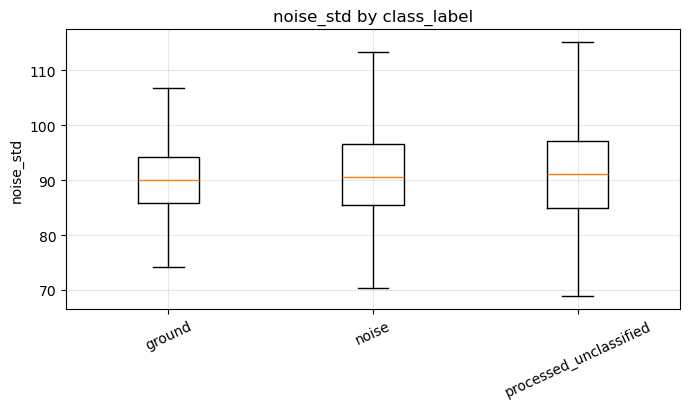

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


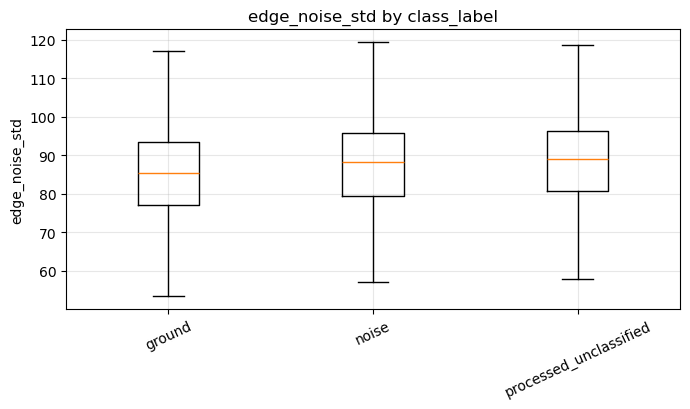

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


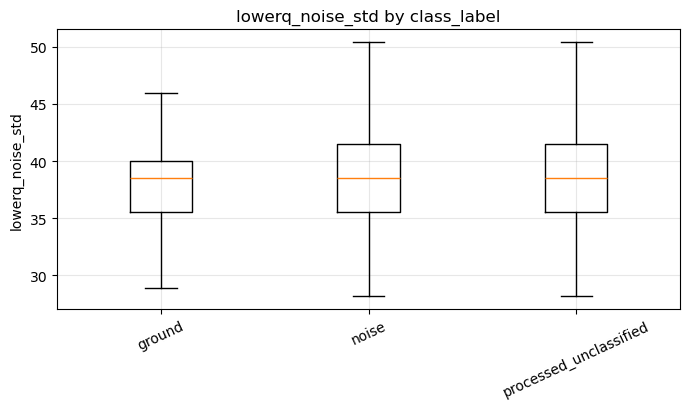

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


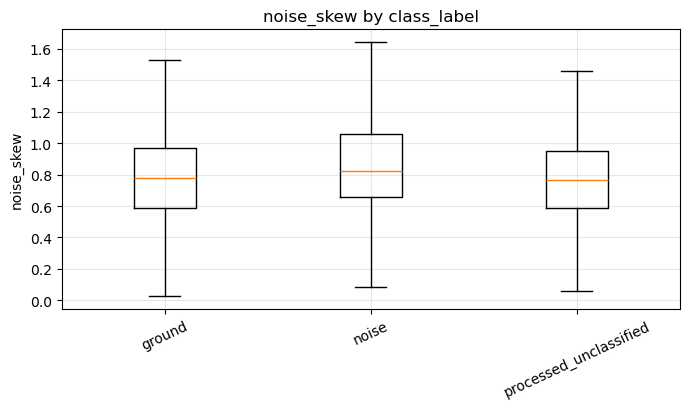

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


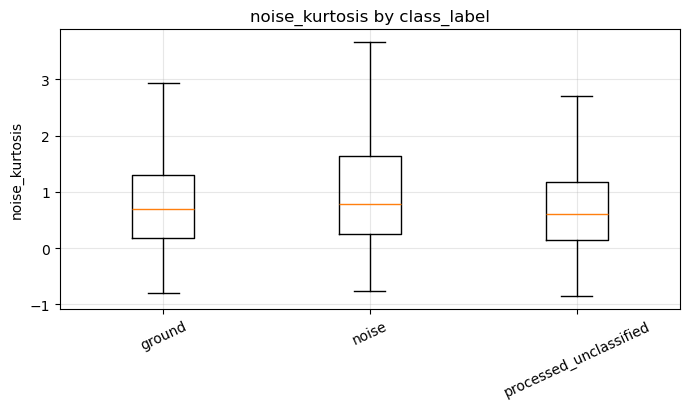

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


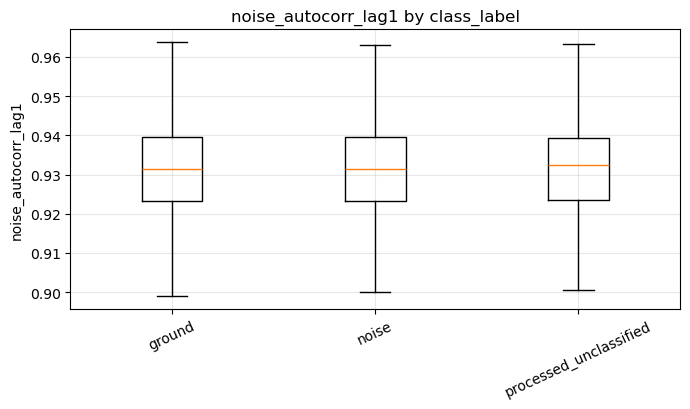

In [12]:
def plot_box_by_group(df: pd.DataFrame, feature: str, group_col: str = "class_label", title: str | None = None) -> None:
    if feature not in df.columns or group_col not in df.columns:
        print(f"Skipping {feature}: missing column.")
        return
    plot_df = df[[group_col, feature]].copy()
    plot_df[feature] = pd.to_numeric(plot_df[feature], errors="coerce")
    plot_df = plot_df[np.isfinite(plot_df[feature])]
    if plot_df.empty:
        print(f"Skipping {feature}: no finite values.")
        return
    groups = [g[feature].to_numpy(dtype=np.float64) for _, g in plot_df.groupby(group_col, sort=True)]
    labels = [str(k) for k, _ in plot_df.groupby(group_col, sort=True)]
    fig, ax = plt.subplots(figsize=(max(7, 1.2 * len(labels)), 4.2))
    ax.boxplot(groups, labels=labels, showfliers=False)
    ax.set_ylabel(feature)
    ax.set_title(title or f"{feature} by {group_col}")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


for feature in ["noise_std", "edge_noise_std", "lowerq_noise_std", "noise_skew", "noise_kurtosis", "noise_autocorr_lag1"]:
    plot_box_by_group(analysis_df, feature, "class_label")

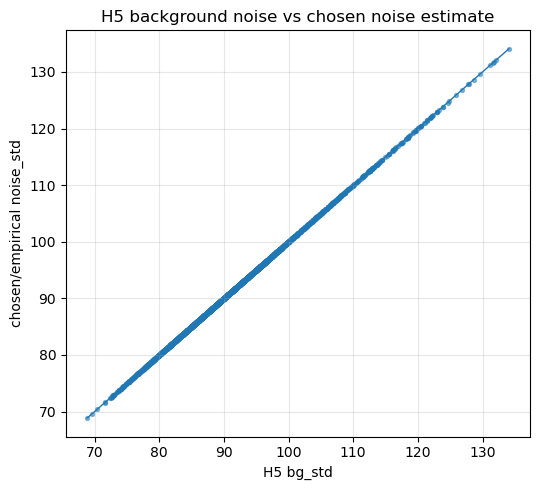

In [13]:
if {"h5_bg_std", "noise_std"}.issubset(analysis_df.columns):
    plot_df = analysis_df.copy()
    plot_df["h5_bg_std"] = pd.to_numeric(plot_df["h5_bg_std"], errors="coerce")
    plot_df["noise_std"] = pd.to_numeric(plot_df["noise_std"], errors="coerce")
    plot_df = plot_df[np.isfinite(plot_df["h5_bg_std"]) & np.isfinite(plot_df["noise_std"])]
    if not plot_df.empty:
        fig, ax = plt.subplots(figsize=(5.5, 5.0))
        ax.scatter(plot_df["h5_bg_std"], plot_df["noise_std"], s=8, alpha=0.5)
        lo = float(np.nanmin([plot_df["h5_bg_std"].min(), plot_df["noise_std"].min()]))
        hi = float(np.nanmax([plot_df["h5_bg_std"].max(), plot_df["noise_std"].max()]))
        ax.plot([lo, hi], [lo, hi], linewidth=1.0)
        ax.set_xlabel("H5 bg_std")
        ax.set_ylabel("chosen/empirical noise_std")
        ax.set_title("H5 background noise vs chosen noise estimate")
        ax.grid(alpha=0.3)
        fig.tight_layout()
        plt.show()

## Peak dominance and waveform ambiguity diagnostics

Peak-ratio features are interpreted as peak dominance. A small ratio can mean true multiple returns, not necessarily noise. The most useful evidence is whether problematic error groups differ from correct processed or correct ground points.

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


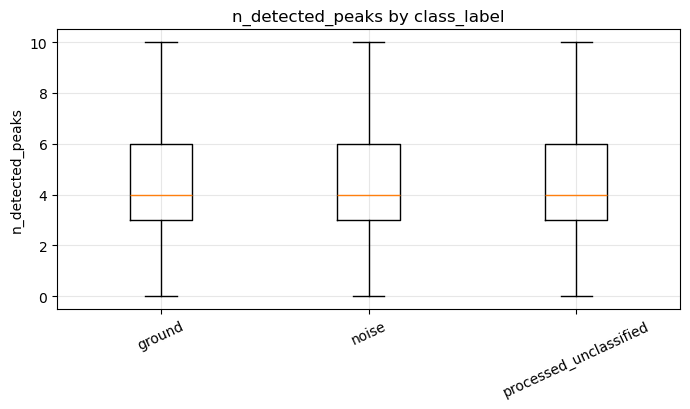

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


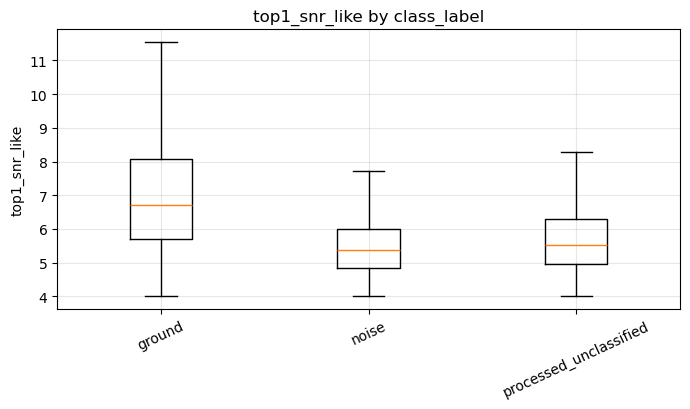

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


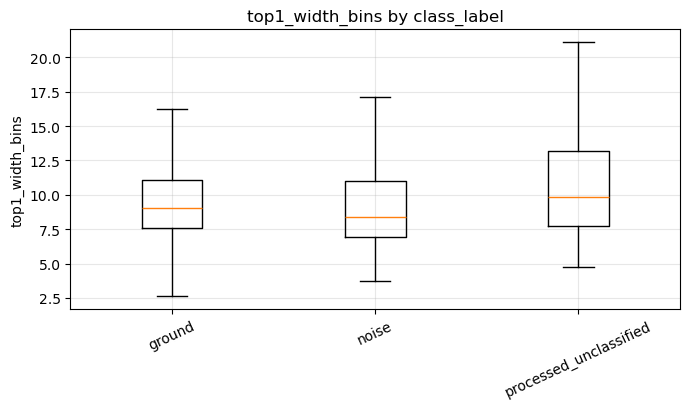

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


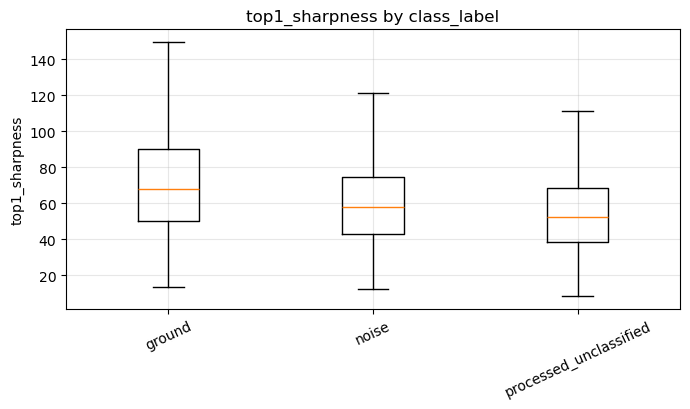

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


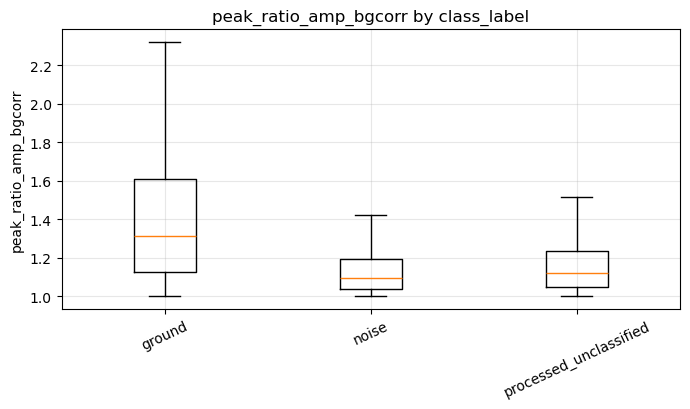

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


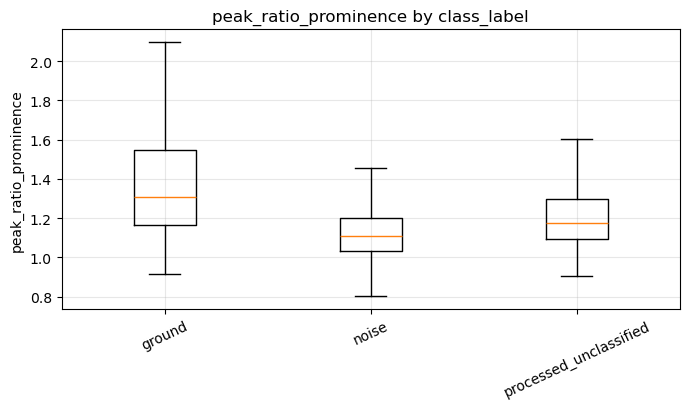

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


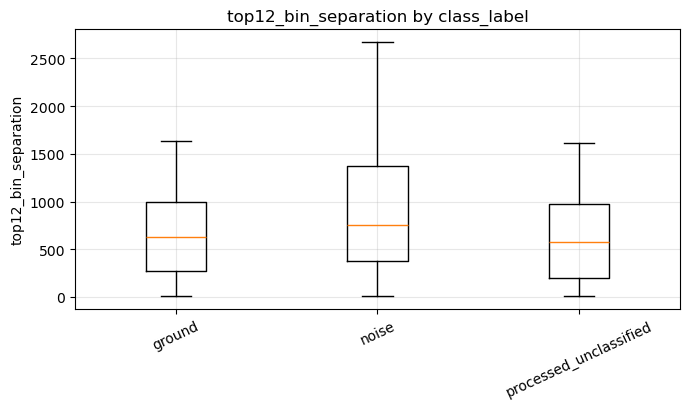

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


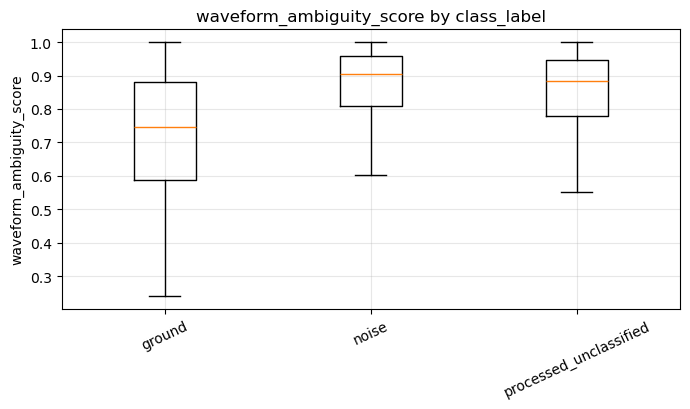

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


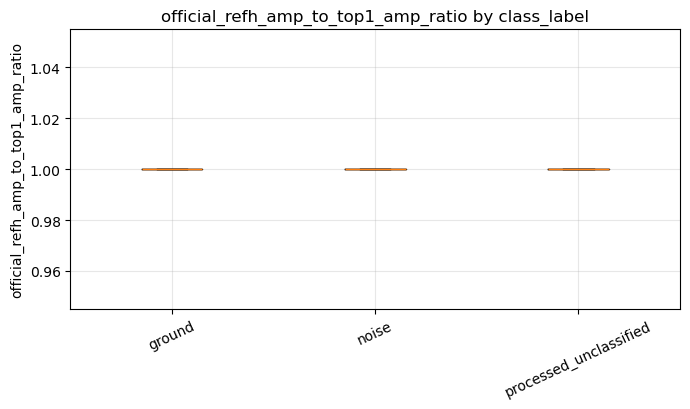

In [14]:
for feature in [
    "n_detected_peaks", "top1_snr_like", "top1_width_bins", "top1_sharpness",
    "peak_ratio_amp_bgcorr", "peak_ratio_prominence", "top12_bin_separation",
    "waveform_ambiguity_score", "official_refh_amp_to_top1_amp_ratio",
]:
    plot_box_by_group(analysis_df, feature, "class_label")

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


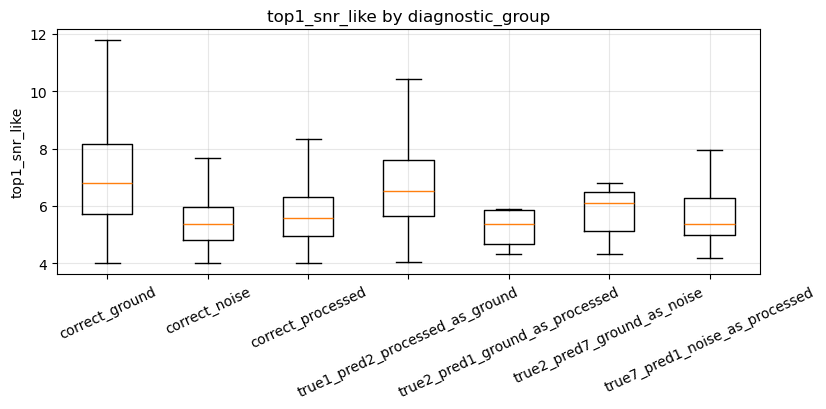

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


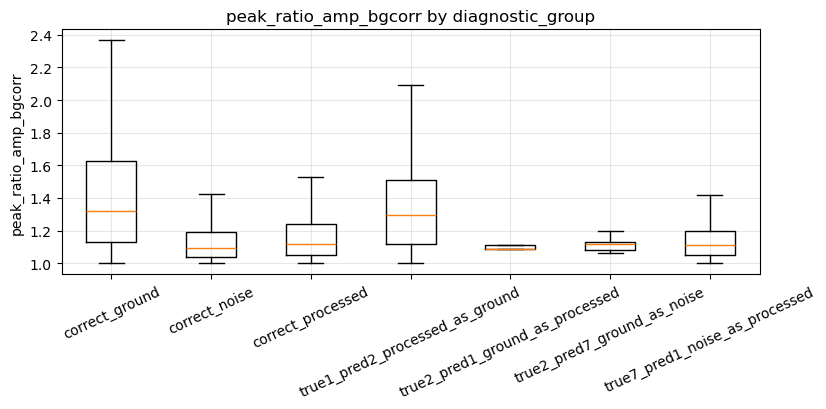

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


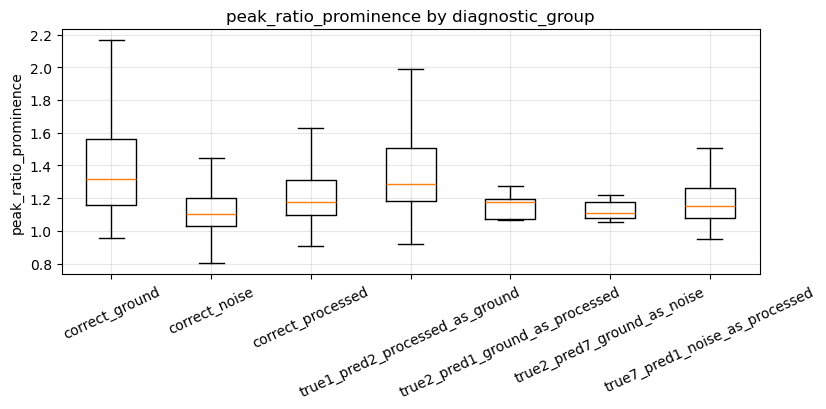

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


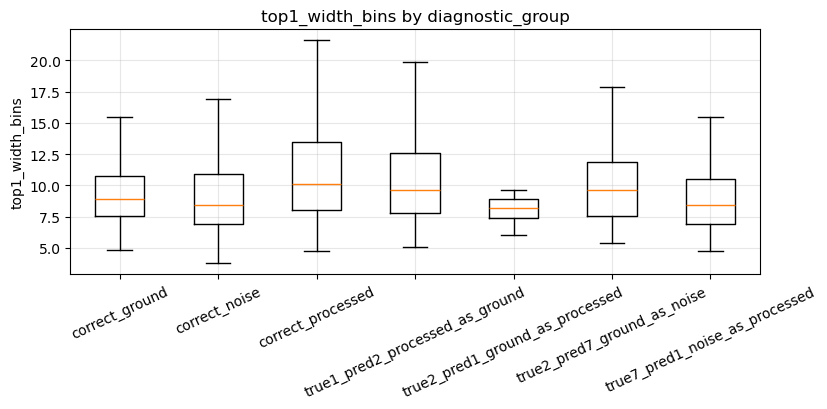

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


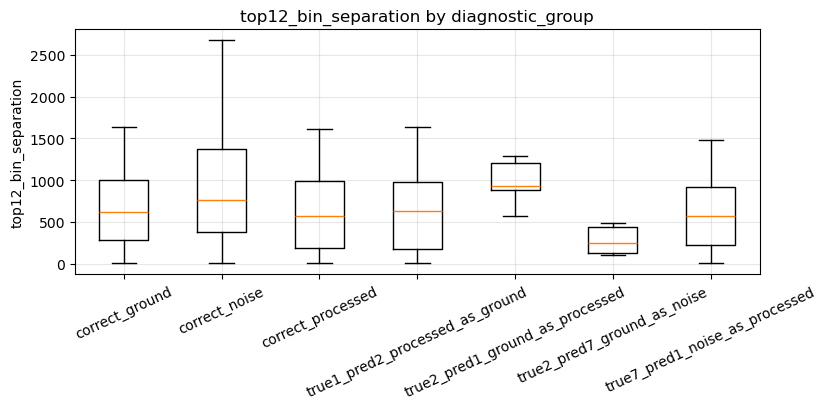

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


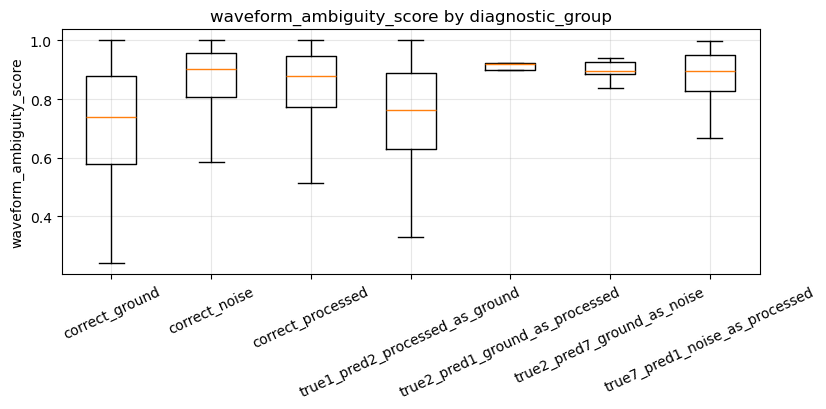

C:\Users\zhong267\AppData\Local\Temp\ipykernel_69196\2302491115.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


Skipping refh_to_top1_bin_delta: no finite values.


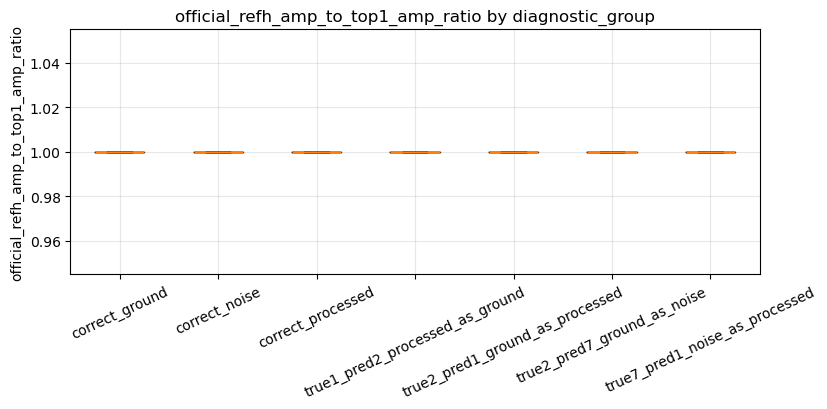

In [15]:
if "diagnostic_group" in analysis_df.columns:
    interesting_groups = [
        "correct_ground", "correct_processed", "correct_noise",
        "true7_pred1_noise_as_processed",
        "true1_pred2_processed_as_ground",
        "true2_pred7_ground_as_noise",
        "true2_pred1_ground_as_processed",
    ]
    group_df = analysis_df[analysis_df["diagnostic_group"].isin(interesting_groups)].copy()
    if not group_df.empty:
        for feature in [
            "top1_snr_like", "peak_ratio_amp_bgcorr", "peak_ratio_prominence",
            "top1_width_bins", "top12_bin_separation", "waveform_ambiguity_score",
            "refh_to_top1_bin_delta", "official_refh_amp_to_top1_amp_ratio",
        ]:
            plot_box_by_group(group_df, feature, "diagnostic_group")
    else:
        print("No matched diagnostic groups available; this is expected for H5-only sampling or LAZ without eval_gt_class.")

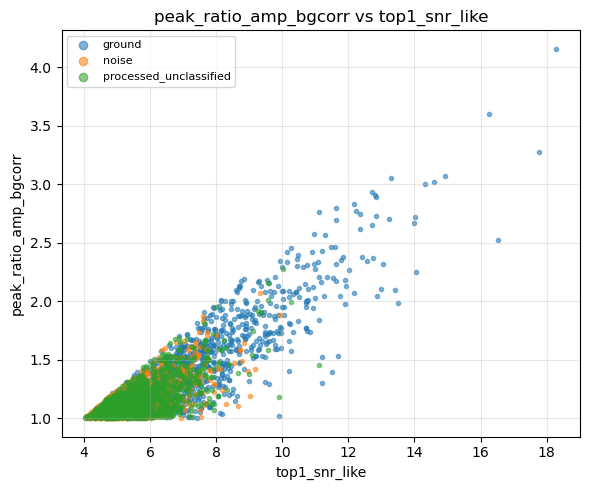

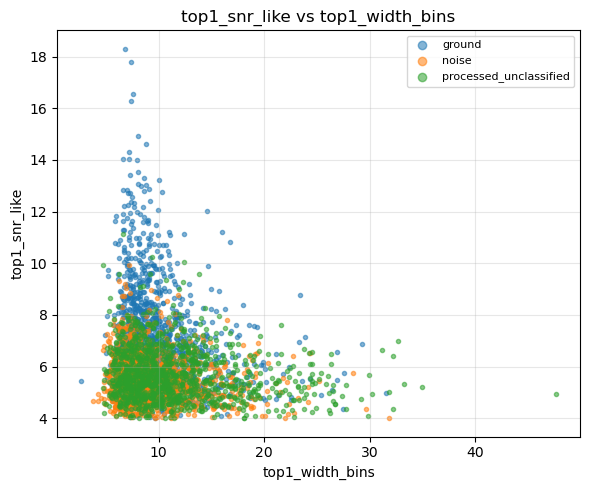

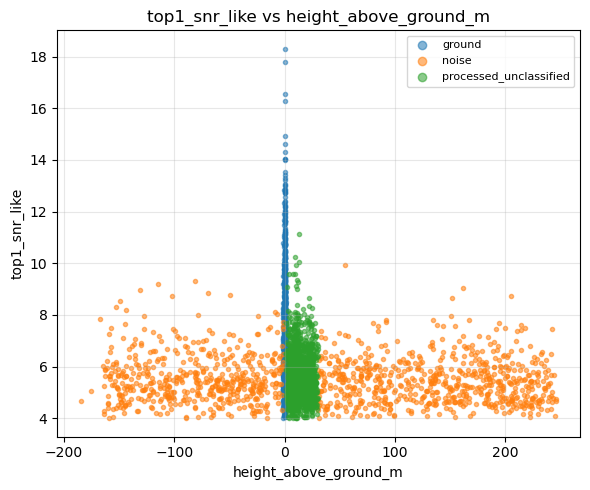

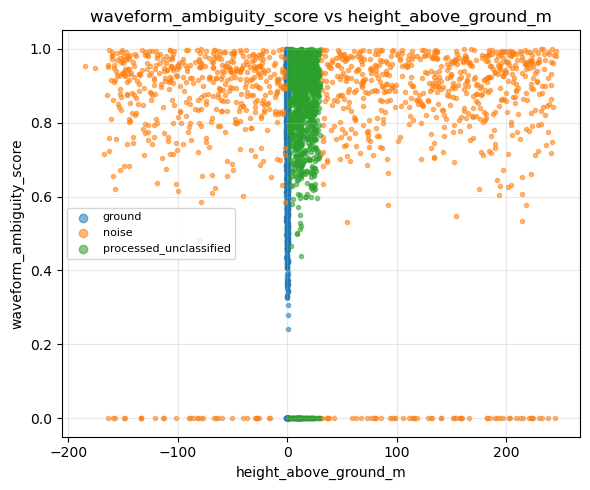

In [16]:
def scatter_feature_pair(df: pd.DataFrame, x_col: str, y_col: str, group_col: str = "class_label") -> None:
    if not {x_col, y_col, group_col}.issubset(df.columns):
        print(f"Skipping scatter {x_col} vs {y_col}: missing columns.")
        return
    plot_df = df[[x_col, y_col, group_col]].copy()
    plot_df[x_col] = pd.to_numeric(plot_df[x_col], errors="coerce")
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df = plot_df[np.isfinite(plot_df[x_col]) & np.isfinite(plot_df[y_col])]
    if plot_df.empty:
        print(f"Skipping scatter {x_col} vs {y_col}: no finite values.")
        return
    fig, ax = plt.subplots(figsize=(6.0, 5.0))
    for group_value, g in plot_df.groupby(group_col):
        ax.scatter(g[x_col], g[y_col], s=9, alpha=0.55, label=str(group_value))
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"{y_col} vs {x_col}")
    ax.legend(markerscale=2, fontsize=8)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


scatter_feature_pair(analysis_df, "top1_snr_like", "peak_ratio_amp_bgcorr", "class_label")
scatter_feature_pair(analysis_df, "top1_width_bins", "top1_snr_like", "class_label")
if "height_above_ground_m" in analysis_df.columns:
    scatter_feature_pair(analysis_df, "height_above_ground_m", "top1_snr_like", "class_label")
    scatter_feature_pair(analysis_df, "height_above_ground_m", "waveform_ambiguity_score", "class_label")

## Representative raw waveform diagnostics

This section plots raw waveform amplitudes only. Peak detection is based on the raw background-corrected waveform. No smoothed curve is shown. If the RX bin time interval is available, each figure includes a 10 m one-way range scale bar computed from:

\[
\Delta R = \frac{c}{2n} \Delta t
\]

where \(\Delta t\) is the RX bin time interval, \(c\) is the speed of light, and \(n\) is the refractive index used in the configuration.


,h5_row,class_label,diagnostic_group,n_detected_peaks,top1_snr_like,peak_ratio_amp_bgcorr,top12_bin_separation
6,87,processed_unclassified,true7_pred1_noise_as_processed,6,5.262330,1.093830,92.0
14,152,processed_unclassified,true7_pred1_noise_as_processed,5,7.483574,1.321593,1402.0
29,279,processed_unclassified,true7_pred1_noise_as_processed,4,5.675811,1.237911,89.0
38,344,processed_unclassified,true7_pred1_noise_as_processed,2,4.489108,1.007893,660.0
2400,2,noise,correct_noise,9,5.845320,1.285176,232.0
2401,3,noise,correct_noise,4,5.765897,1.087392,752.0
2402,5,noise,correct_noise,11,8.973903,1.405550,76.0
2403,6,noise,correct_noise,10,5.951861,1.091311,2421.0
0,0,processed_unclassified,correct_processed,2,5.150645,1.166031,292.0
1,13,processed_unclassified,correct_processed,4,5.563639,1.133999,1353.0


read H5 waveform rows 0-1 / 1


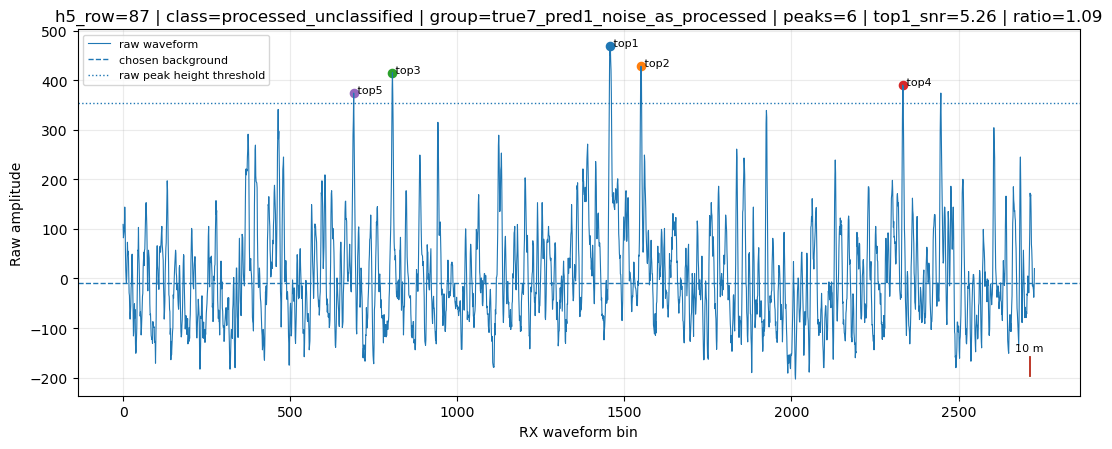

read H5 waveform rows 0-1 / 1


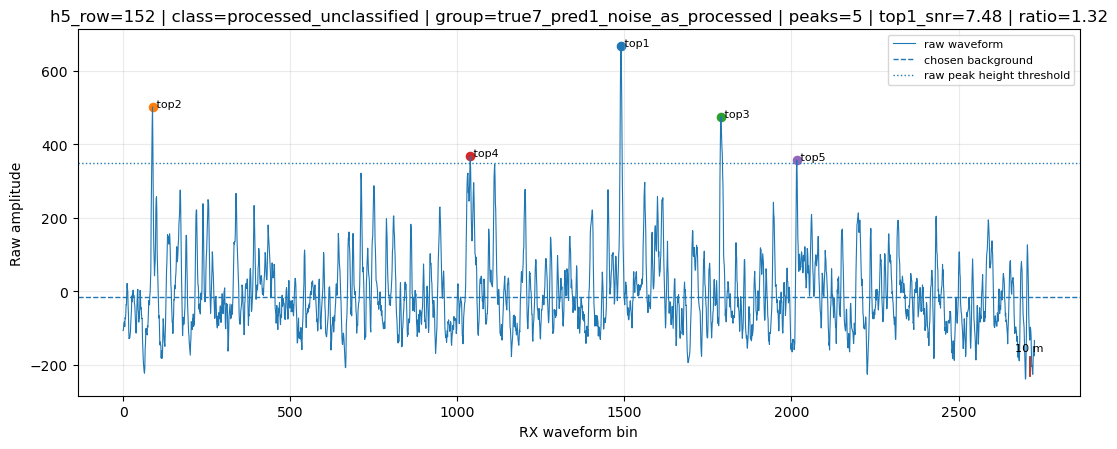

read H5 waveform rows 0-1 / 1


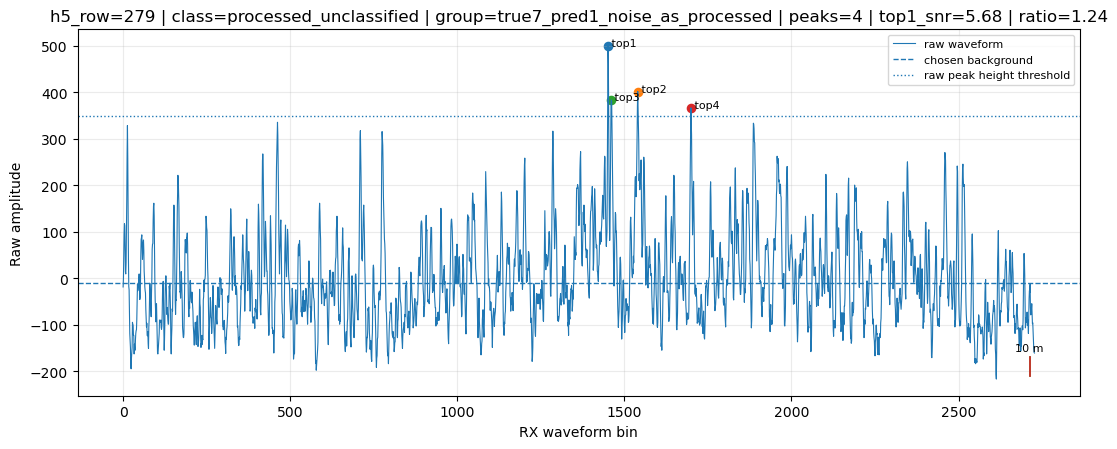

read H5 waveform rows 0-1 / 1


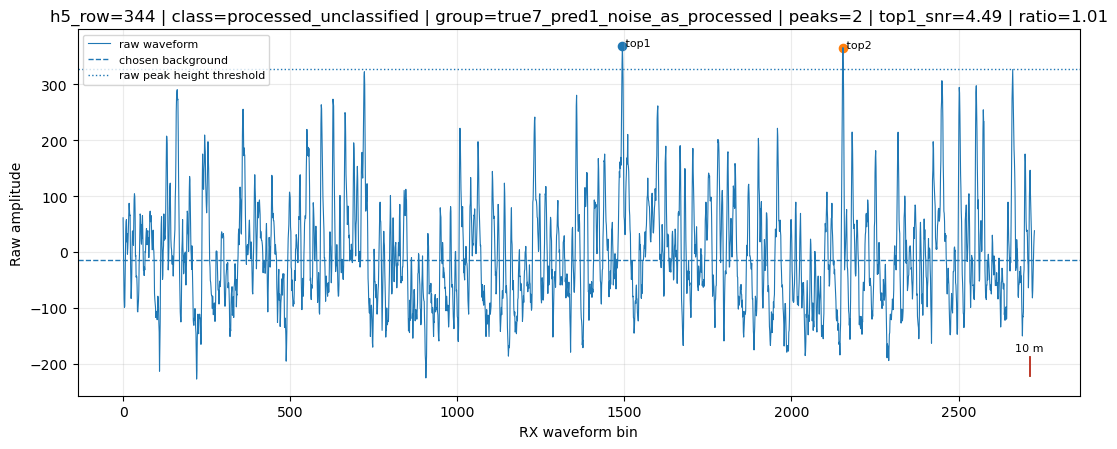

read H5 waveform rows 0-1 / 1


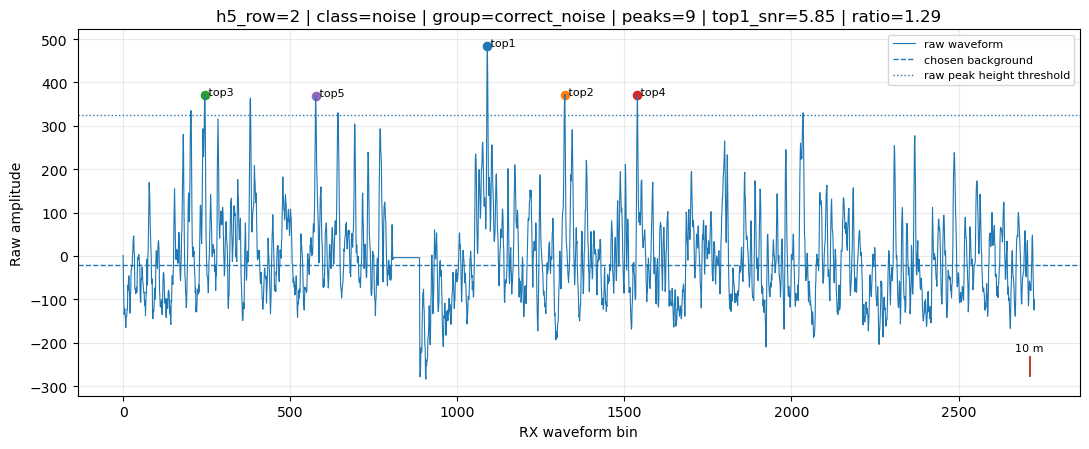

read H5 waveform rows 0-1 / 1


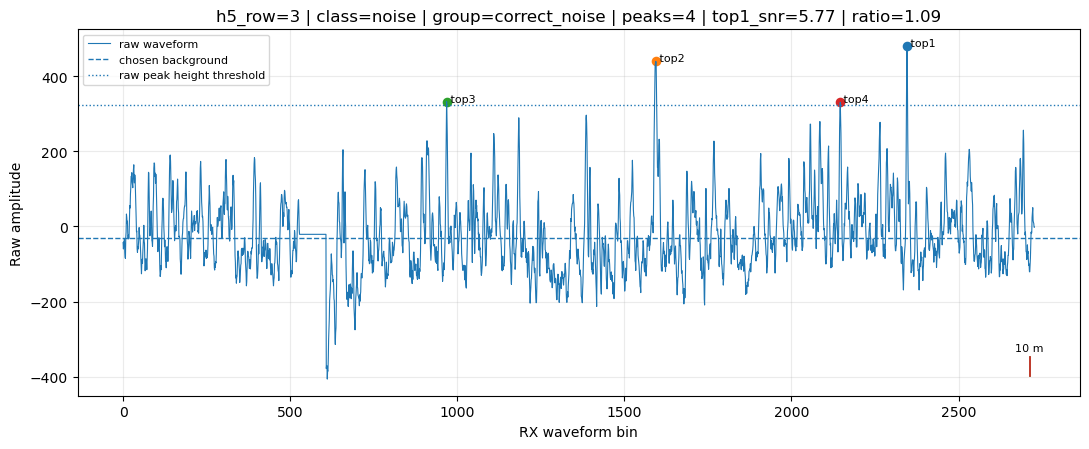

read H5 waveform rows 0-1 / 1


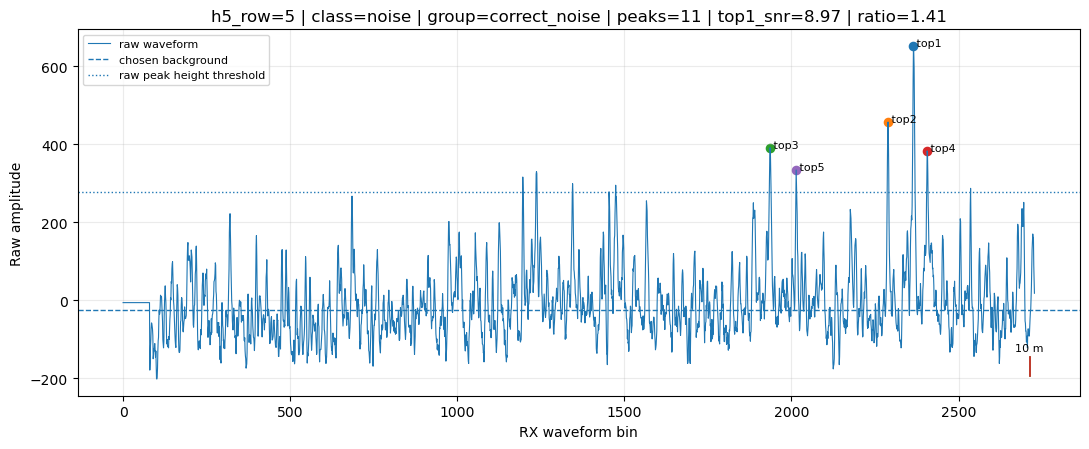

read H5 waveform rows 0-1 / 1


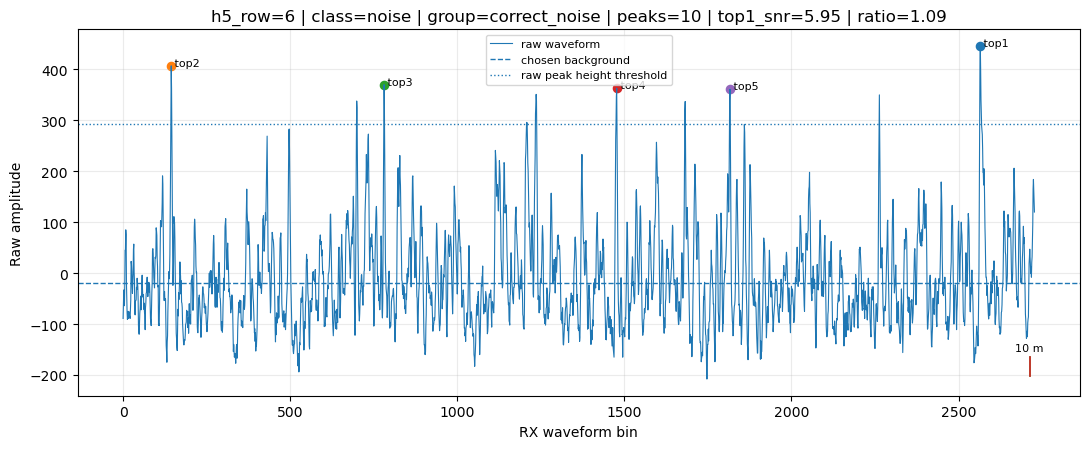

read H5 waveform rows 0-1 / 1


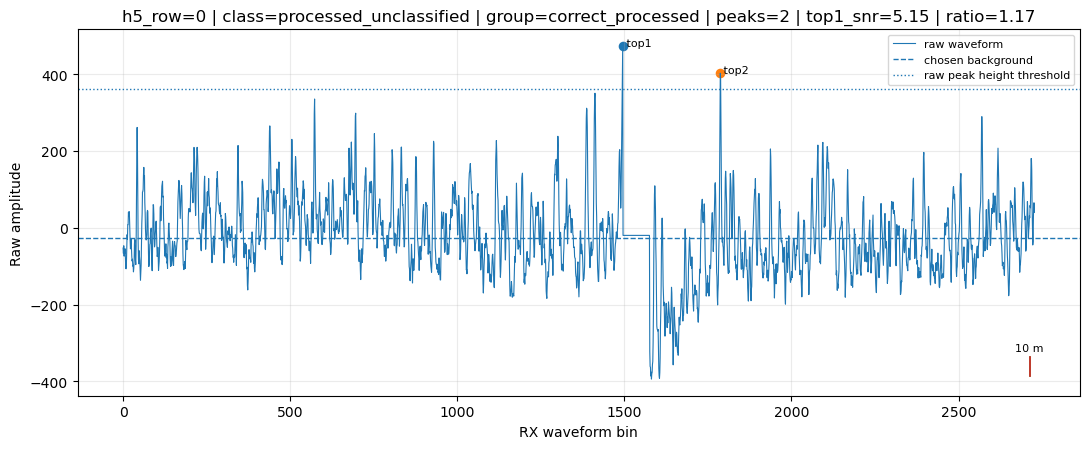

read H5 waveform rows 0-1 / 1


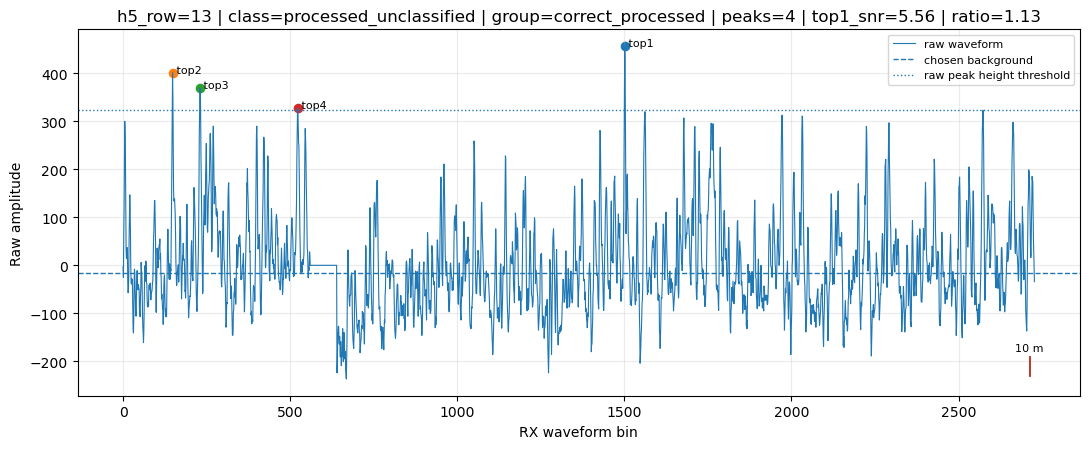

read H5 waveform rows 0-1 / 1


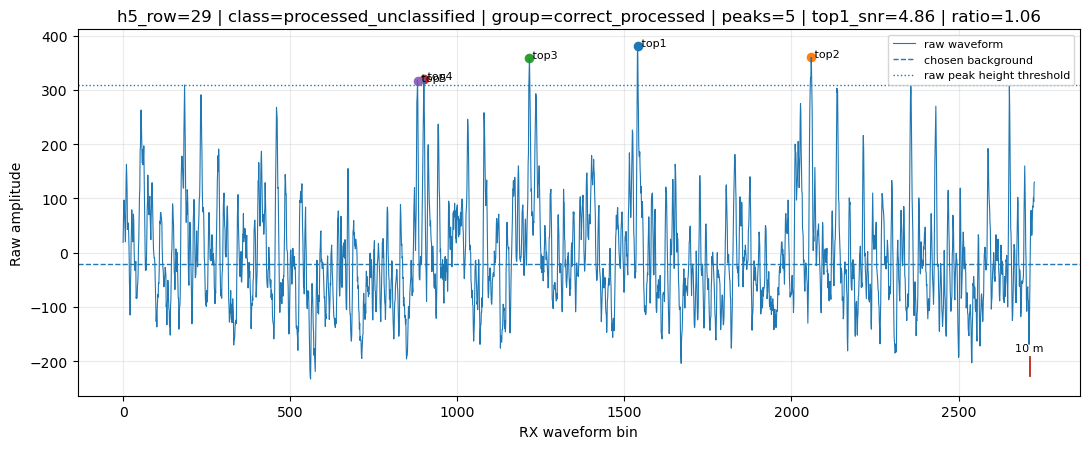

read H5 waveform rows 0-1 / 1


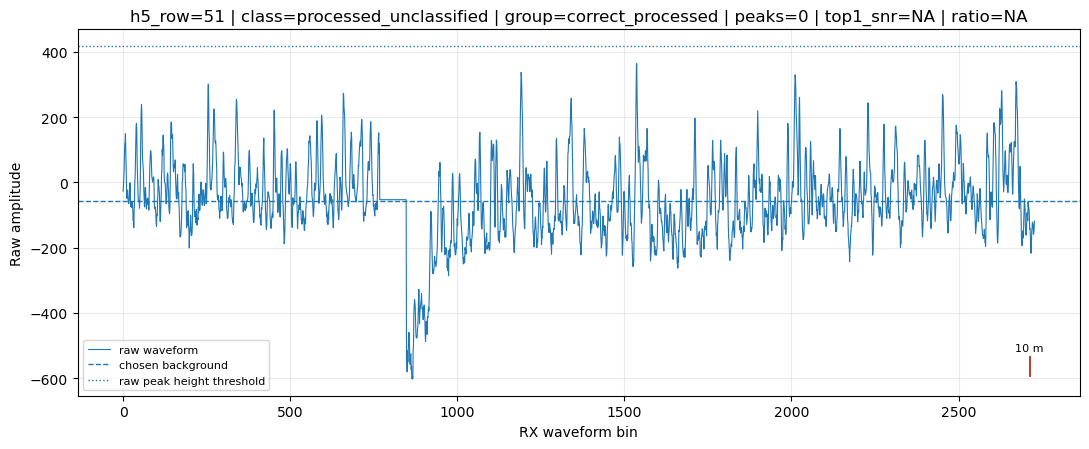

read H5 waveform rows 0-1 / 1


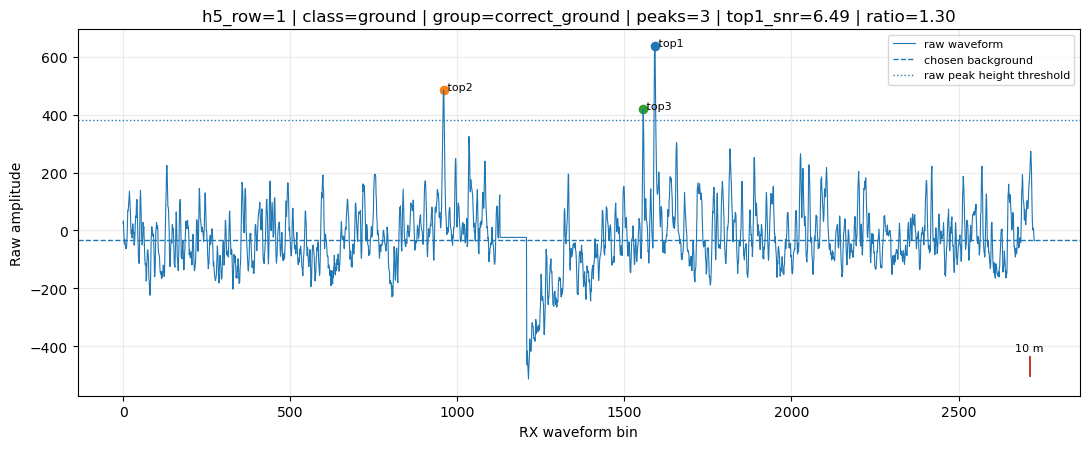

read H5 waveform rows 0-1 / 1


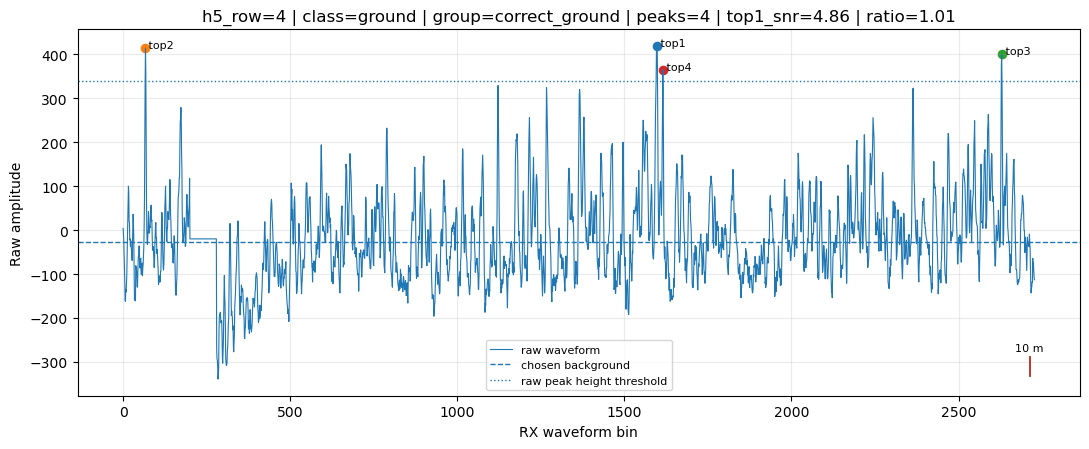

read H5 waveform rows 0-1 / 1


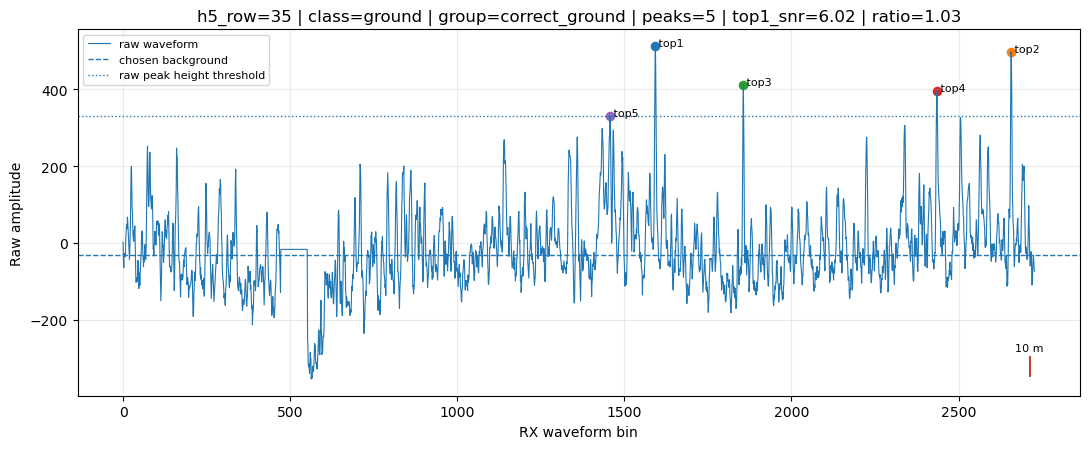

read H5 waveform rows 0-1 / 1


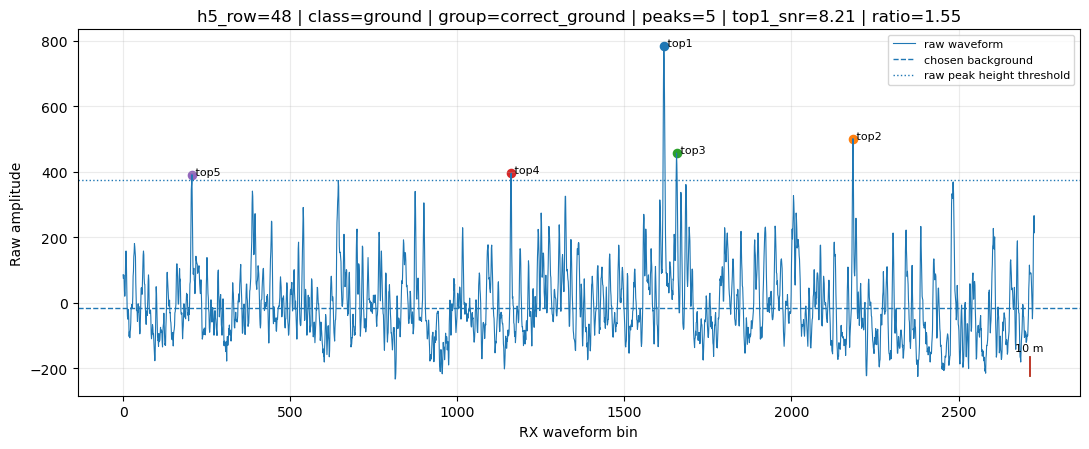

read H5 waveform rows 0-1 / 1


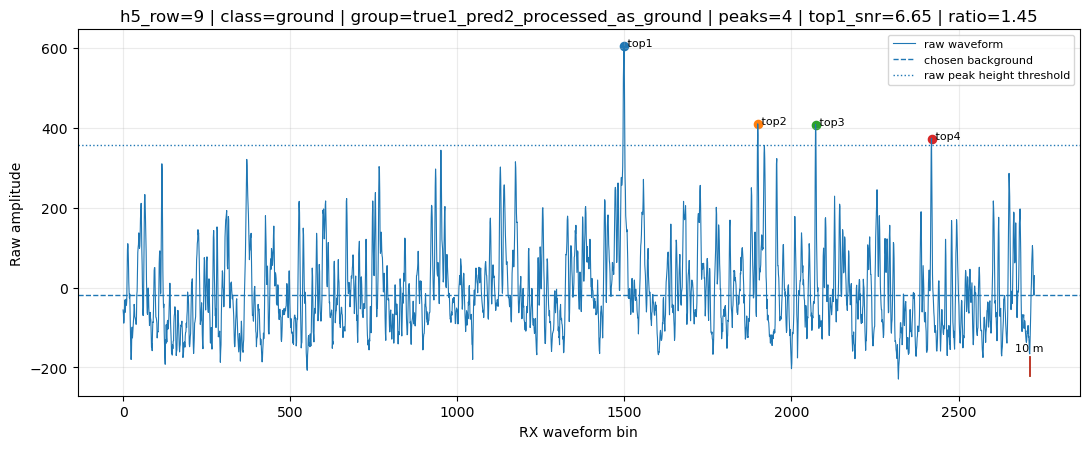

read H5 waveform rows 0-1 / 1


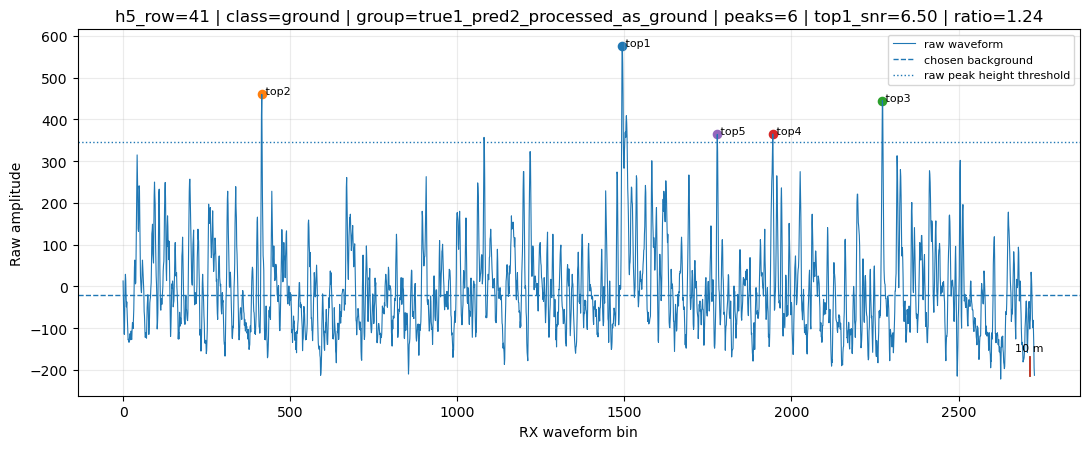

read H5 waveform rows 0-1 / 1


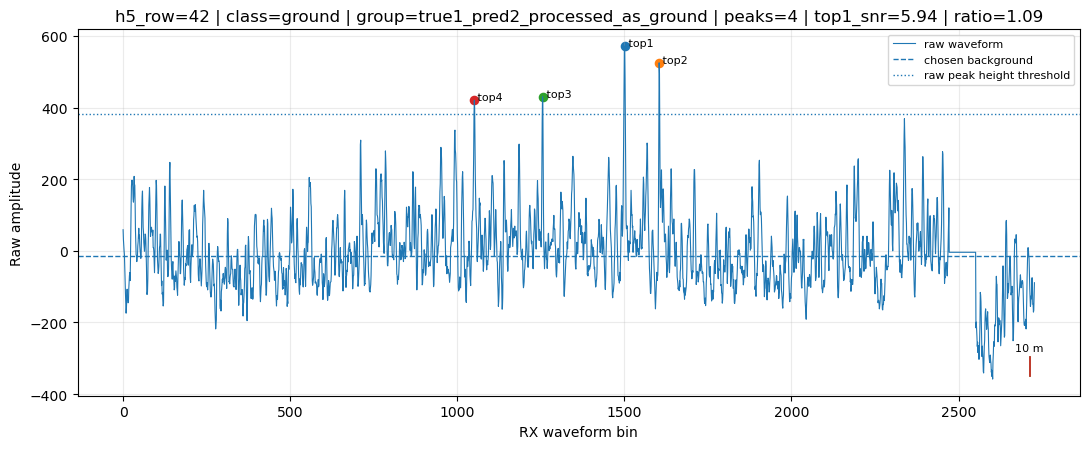

read H5 waveform rows 0-1 / 1


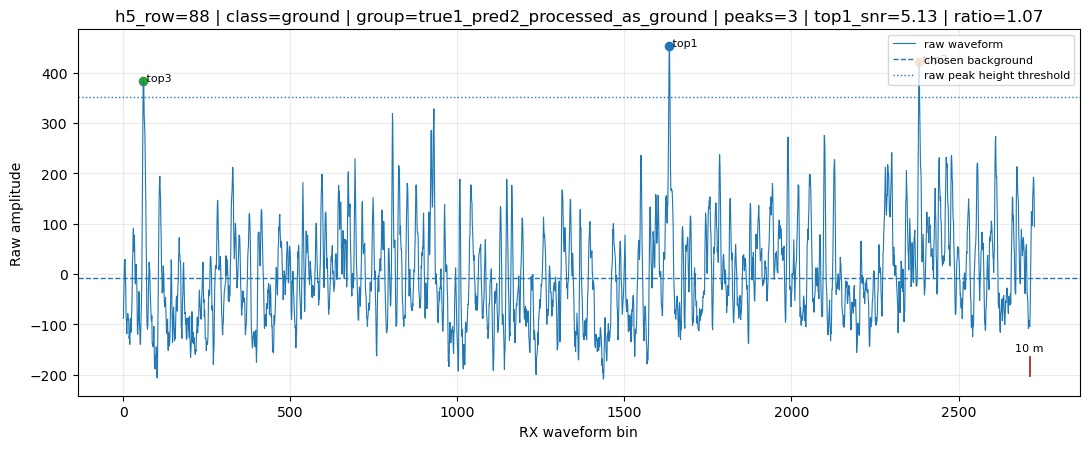

read H5 waveform rows 0-1 / 1


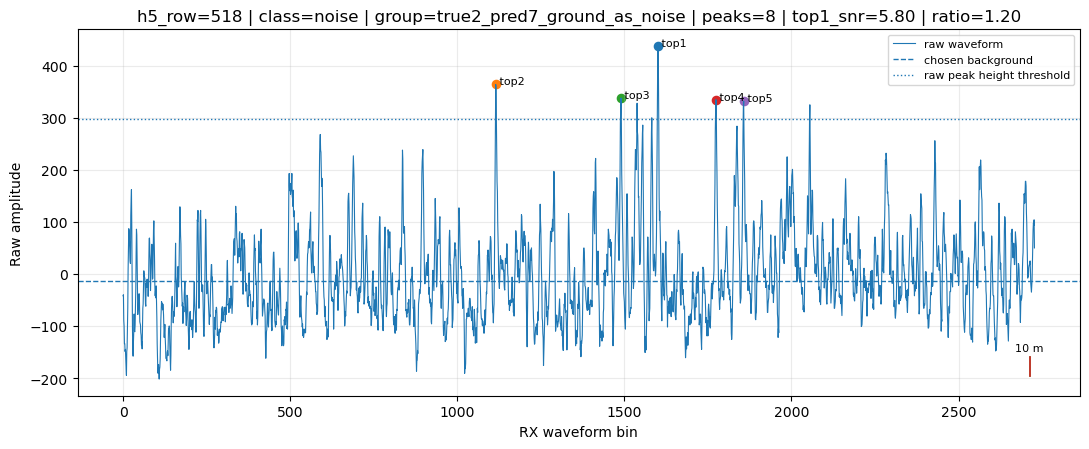

read H5 waveform rows 0-1 / 1


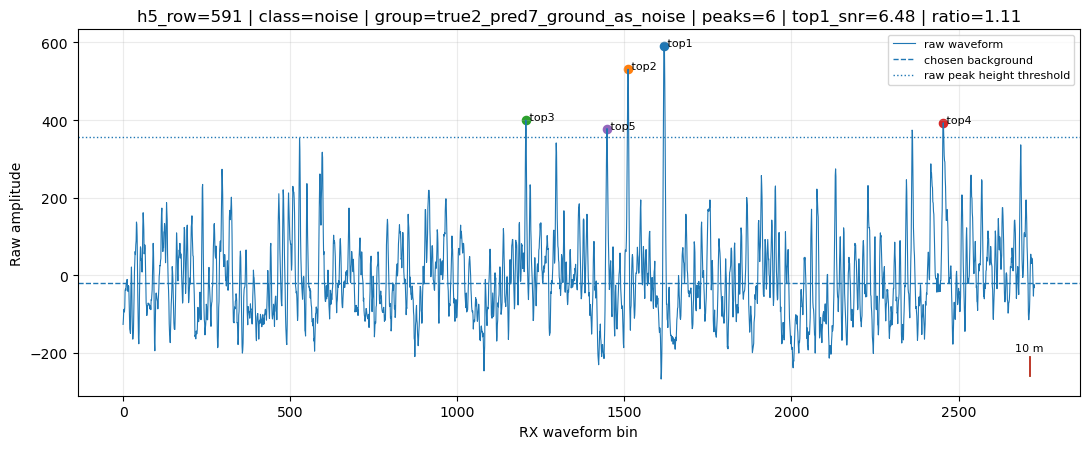

read H5 waveform rows 0-1 / 1


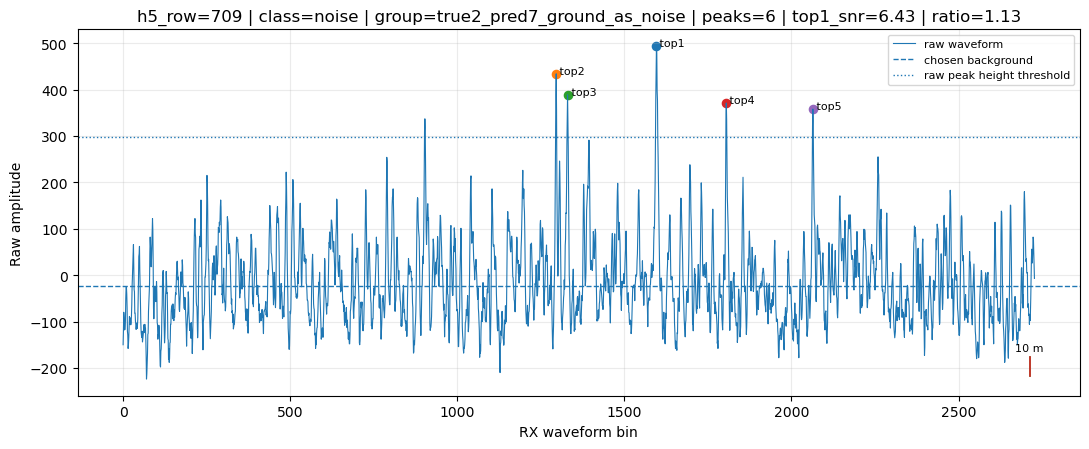

read H5 waveform rows 0-1 / 1


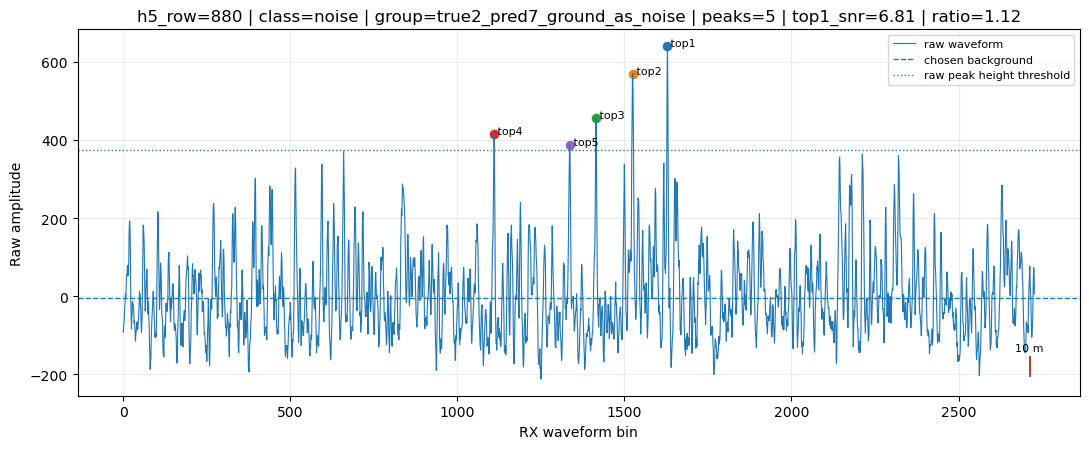

In [17]:
def select_representative_rows(df: pd.DataFrame, n_rows: int) -> pd.DataFrame:
    candidates = []
    if "diagnostic_group" in df.columns:
        preferred = [
            "true7_pred1_noise_as_processed", "correct_noise", "correct_processed", "correct_ground",
            "true1_pred2_processed_as_ground", "true2_pred7_ground_as_noise",
        ]
        for group in preferred:
            g = df[df["diagnostic_group"] == group]
            if not g.empty:
                candidates.append(g.head(max(1, n_rows // max(1, len(preferred)))))
    if candidates:
        rep = pd.concat(candidates, ignore_index=False).drop_duplicates(subset=["h5_row"])
    else:
        rep = df.head(n_rows)
    if rep.shape[0] < n_rows:
        extra = df[~df["h5_row"].isin(rep["h5_row"])].head(n_rows - rep.shape[0])
        rep = pd.concat([rep, extra], ignore_index=False)
    return rep.head(n_rows)


def add_range_scale_bar(ax: plt.Axes, scale_info: dict[str, Any]) -> None:
    if not SHOW_10M_SCALE_BAR or not scale_info.get("available", False):
        return

    length_bins = float(scale_info["scale_bar_bins"])
    if not np.isfinite(length_bins) or length_bins <= 0:
        return

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    x_span = float(x_max - x_min)
    y_span = float(y_max - y_min)
    if x_span <= 0 or y_span <= 0:
        return

    if length_bins > 0.80 * x_span:
        ax.text(
            x_min + 0.02 * x_span,
            y_min + 0.08 * y_span,
            f"{scale_info['scale_bar_range_m']:g} m scale = {length_bins:.1f} bins, longer than visible axis",
            fontsize=8,
            va="bottom",
        )
        return

    x0 = x_max - length_bins - 0.05 * x_span
    x1 = x0 + length_bins
    y0 = y_min + 0.08 * y_span
    tick = 0.025 * y_span
    ax.plot([x0, x1], [y0, y0], linewidth=2.0)
    ax.plot([x0, x0], [y0 - tick, y0 + tick], linewidth=1.2)
    ax.plot([x1, x1], [y0 - tick, y0 + tick], linewidth=1.2)
    ax.text(
        (x0 + x1) / 2.0,
        y0 + 1.5 * tick,
        f"{scale_info['scale_bar_range_m']:g} m",
        ha="center",
        va="bottom",
        fontsize=8,
    )


def maybe_add_secondary_range_axis(ax: plt.Axes, scale_info: dict[str, Any]) -> None:
    if not SHOW_SECONDARY_RANGE_AXIS or not scale_info.get("available", False):
        return
    bin_spacing = float(scale_info["bin_one_way_range_m"])
    if not np.isfinite(bin_spacing) or bin_spacing <= 0:
        return

    def bin_to_range_m(x):
        return np.asarray(x) * bin_spacing

    def range_m_to_bin(x):
        return np.asarray(x) / bin_spacing

    secax = ax.secondary_xaxis("top", functions=(bin_to_range_m, range_m_to_bin))
    secax.set_xlabel("Relative one-way range from bin 0 (m)")


def plot_waveform_with_diagnostics(row: pd.Series) -> None:
    row_index = int(row["h5_row"])
    wf = read_h5_waveform_rows(h5_path, rx_path, np.asarray([row_index], dtype=np.int64), 1)[0].astype(np.float64)
    bins = np.arange(wf.size)
    bg = float(row.get("background_mean", np.nan))
    noise = float(row.get("noise_std", MIN_NOISE_STD))

    fig, ax = plt.subplots(figsize=(11.0, 4.6))
    ax.plot(bins, wf, linewidth=0.8, label="raw waveform")
    if np.isfinite(bg):
        ax.axhline(bg, linewidth=1.0, linestyle="--", label="chosen background")
        ax.axhline(bg + PEAK_HEIGHT_MIN_SIGMA * noise, linewidth=1.0, linestyle=":", label="raw peak height threshold")

    for k in range(1, TOP_K_PEAKS_TO_STORE + 1):
        peak_bin = row.get(f"top{k}_bin", np.nan)
        peak_amp = row.get(f"top{k}_amp_raw", np.nan)
        if np.isfinite(peak_bin) and np.isfinite(peak_amp):
            ax.scatter([peak_bin], [peak_amp], s=35)
            ax.text(float(peak_bin), float(peak_amp), f" top{k}", fontsize=8)

    add_range_scale_bar(ax, range_scale_info)
    maybe_add_secondary_range_axis(ax, range_scale_info)

    title_parts = [
        f"h5_row={row_index}",
        f"class={row.get('class_label', 'NA')}",
        f"group={row.get('diagnostic_group', 'NA')}",
        f"peaks={int(row.get('n_detected_peaks', -1)) if pd.notna(row.get('n_detected_peaks', np.nan)) else 'NA'}",
        f"top1_snr={row.get('top1_snr_like', np.nan):.2f}" if np.isfinite(row.get('top1_snr_like', np.nan)) else "top1_snr=NA",
        f"ratio={row.get('peak_ratio_amp_bgcorr', np.nan):.2f}" if np.isfinite(row.get('peak_ratio_amp_bgcorr', np.nan)) else "ratio=NA",
    ]
    ax.set_title(" | ".join(title_parts))
    ax.set_xlabel("RX waveform bin")
    ax.set_ylabel("Raw amplitude")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()


representative_df = select_representative_rows(analysis_df, N_REPRESENTATIVE_WAVEFORMS)
display(representative_df[[
    "h5_row", "class_label", "diagnostic_group", "n_detected_peaks",
    "top1_snr_like", "peak_ratio_amp_bgcorr", "top12_bin_separation"
]].head(N_REPRESENTATIVE_WAVEFORMS))

for _, row in representative_df.iterrows():
    plot_waveform_with_diagnostics(row)


## Scanline consistency of waveform diagnostics

If `track_num` or `sweep_num` is available, compute robust group-wise z-scores for waveform features. These features are useful for identifying striping artifacts or systematic range-window reflections that may not look like random noise in individual waveforms.

In [18]:
def compute_group_robust_z(values: np.ndarray, groups: np.ndarray, min_group_size: int = 20) -> np.ndarray:
    arr = np.asarray(values, dtype=np.float64)
    grp = np.asarray(groups)
    out = np.full(arr.shape, np.nan, dtype=np.float64)
    finite = np.isfinite(arr) & pd.notna(grp)
    if not np.any(finite):
        return out
    df_tmp = pd.DataFrame({"idx": np.flatnonzero(finite), "group": grp[finite], "value": arr[finite]})
    for _, g in df_tmp.groupby("group"):
        if len(g) < min_group_size:
            continue
        med, nmad = robust_median_nmad(g["value"].to_numpy(dtype=np.float64))
        if np.isfinite(med) and np.isfinite(nmad) and nmad > 0:
            out[g["idx"].to_numpy(dtype=np.int64)] = np.abs(g["value"].to_numpy(dtype=np.float64) - med) / nmad
    return out


for group_col in ["h5_track_num", "h5_sweep_num", "track_num", "sweep_num"]:
    if group_col not in analysis_df.columns:
        continue
    for feature in ["top1_snr_like", "peak_ratio_amp_bgcorr", "top1_bin", "top1_width_bins", "waveform_ambiguity_score"]:
        if feature in analysis_df.columns:
            z_col = f"{feature}_robust_z_by_{group_col}"
            analysis_df[z_col] = compute_group_robust_z(
                pd.to_numeric(analysis_df[feature], errors="coerce").to_numpy(dtype=np.float64),
                analysis_df[group_col].to_numpy(),
                min_group_size=20,
            )

scanline_z_cols = [c for c in analysis_df.columns if c.endswith("_robust_z_by_h5_track_num") or c.endswith("_robust_z_by_h5_sweep_num")]
print("Computed scanline z-score columns:", scanline_z_cols)
if scanline_z_cols:
    display(summarize_numeric_by_group(analysis_df, "class_label", scanline_z_cols))

Computed scanline z-score columns: ['top1_snr_like_robust_z_by_h5_track_num', 'peak_ratio_amp_bgcorr_robust_z_by_h5_track_num', 'top1_bin_robust_z_by_h5_track_num', 'top1_width_bins_robust_z_by_h5_track_num', 'waveform_ambiguity_score_robust_z_by_h5_track_num', 'top1_snr_like_robust_z_by_h5_sweep_num', 'peak_ratio_amp_bgcorr_robust_z_by_h5_sweep_num', 'top1_bin_robust_z_by_h5_sweep_num', 'top1_width_bins_robust_z_by_h5_sweep_num', 'waveform_ambiguity_score_robust_z_by_h5_sweep_num']


,group,feature,n,p05,median,mean,p95
0,ground,top1_snr_like_robust_z_by_h5_track_num,421,0.031689,0.674491,0.987552,3.205503
1,ground,peak_ratio_amp_bgcorr_robust_z_by_h5_track_num,261,0.070388,0.702978,1.219291,4.054638
2,ground,top1_bin_robust_z_by_h5_track_num,421,0.000000,0.559117,1.714487,10.567022
3,ground,top1_width_bins_robust_z_by_h5_track_num,421,0.022440,0.620899,0.841952,2.656868
4,ground,waveform_ambiguity_score_robust_z_by_h5_track_num,421,0.050564,0.673015,0.826628,2.621201
5,ground,top1_snr_like_robust_z_by_h5_sweep_num,1196,0.062537,0.811723,1.268715,4.059043
6,ground,peak_ratio_amp_bgcorr_robust_z_by_h5_sweep_num,1121,0.083092,0.853474,1.733778,6.087180
7,ground,top1_bin_robust_z_by_h5_sweep_num,1196,0.010539,0.274468,0.429847,1.348982
8,ground,top1_width_bins_robust_z_by_h5_sweep_num,1196,0.046585,0.600328,0.836145,2.628391
9,ground,waveform_ambiguity_score_robust_z_by_h5_sweep_num,1196,0.084630,0.779183,1.226604,4.060474


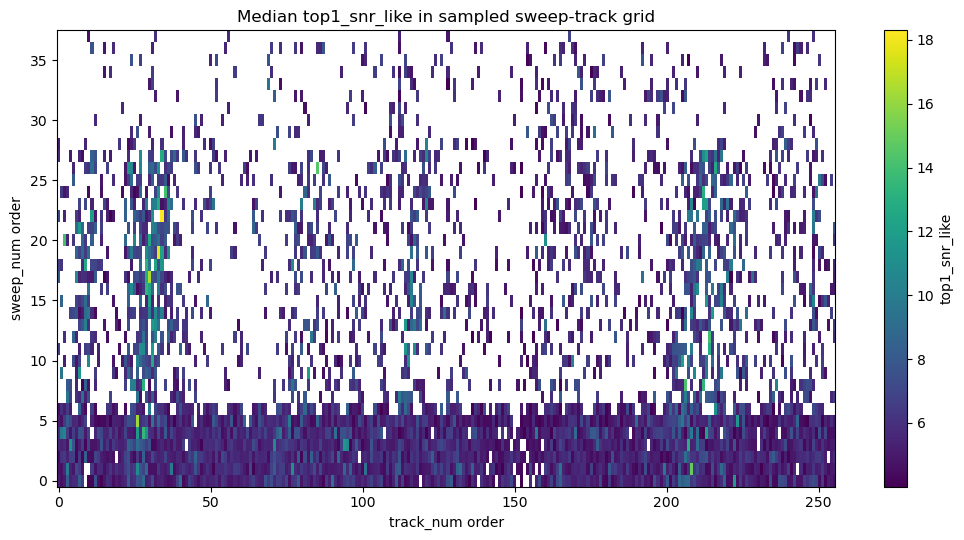

In [19]:
if {"h5_sweep_num", "h5_track_num", "top1_snr_like"}.issubset(analysis_df.columns):
    grid_df = analysis_df.copy()
    grid_df["h5_sweep_num"] = pd.to_numeric(grid_df["h5_sweep_num"], errors="coerce")
    grid_df["h5_track_num"] = pd.to_numeric(grid_df["h5_track_num"], errors="coerce")
    grid_df["top1_snr_like"] = pd.to_numeric(grid_df["top1_snr_like"], errors="coerce")
    grid_df = grid_df[np.isfinite(grid_df["h5_sweep_num"]) & np.isfinite(grid_df["h5_track_num"]) & np.isfinite(grid_df["top1_snr_like"])]
    if not grid_df.empty:
        pivot = grid_df.pivot_table(index="h5_sweep_num", columns="h5_track_num", values="top1_snr_like", aggfunc="median")
        if pivot.size > 0:
            fig, ax = plt.subplots(figsize=(10.5, 5.5))
            im = ax.imshow(pivot.to_numpy(dtype=np.float64), aspect="auto", origin="lower")
            ax.set_title("Median top1_snr_like in sampled sweep-track grid")
            ax.set_xlabel("track_num order")
            ax.set_ylabel("sweep_num order")
            fig.colorbar(im, ax=ax, label="top1_snr_like")
            fig.tight_layout()
            plt.show()

## Conservative waveform-suspicion flags

The following flags are intentionally diagnostic. They are not final classification rules. Use them to test whether waveform evidence can explain current error subsets without harming ground points.

In [20]:
def add_waveform_suspicion_flags(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    top1_snr = pd.to_numeric(out.get("top1_snr_like", np.nan), errors="coerce")
    n_peaks = pd.to_numeric(out.get("n_detected_peaks", np.nan), errors="coerce")
    width = pd.to_numeric(out.get("top1_width_bins", np.nan), errors="coerce")
    ratio = pd.to_numeric(out.get("peak_ratio_amp_bgcorr", np.nan), errors="coerce")
    ambiguity = pd.to_numeric(out.get("waveform_ambiguity_score", np.nan), errors="coerce")
    refh_amp_ratio = pd.to_numeric(out.get("official_refh_amp_to_top1_amp_ratio", np.nan), errors="coerce")

    out["flag_no_detected_peak"] = (n_peaks.fillna(0) <= 0).astype(np.uint8)
    out["flag_low_top1_snr"] = (top1_snr < 5.0).astype(np.uint8)
    out["flag_very_narrow_peak"] = (width < 1.5).astype(np.uint8)
    out["flag_ambiguous_multiple_peaks"] = ((n_peaks >= 2) & np.isfinite(ratio) & (ratio < 1.5)).astype(np.uint8)
    out["flag_high_ambiguity_score"] = (ambiguity > 0.67).astype(np.uint8)
    out["flag_refh_amp_inconsistent_with_top1"] = (np.isfinite(refh_amp_ratio) & ((refh_amp_ratio < 0.5) | (refh_amp_ratio > 1.5))).astype(np.uint8)

    flag_cols = [
        "flag_no_detected_peak", "flag_low_top1_snr", "flag_very_narrow_peak",
        "flag_ambiguous_multiple_peaks", "flag_high_ambiguity_score",
        "flag_refh_amp_inconsistent_with_top1",
    ]
    out["waveform_suspicion_flag_count"] = out[flag_cols].sum(axis=1).astype(np.uint8)
    return out


analysis_df = add_waveform_suspicion_flags(analysis_df)
flag_cols = [c for c in analysis_df.columns if c.startswith("flag_")] + ["waveform_suspicion_flag_count"]
flag_summary = summarize_numeric_by_group(analysis_df, "diagnostic_group", flag_cols)
display(flag_summary)

,group,feature,n,p05,median,mean,p95
0,correct_ground,flag_no_detected_peak,933,0.0,0.0,0.004287,0.0
1,correct_ground,flag_low_top1_snr,933,0.0,0.0,0.081458,1.0
2,correct_ground,flag_very_narrow_peak,933,0.0,0.0,0.000000,0.0
3,correct_ground,flag_ambiguous_multiple_peaks,933,0.0,1.0,0.605573,1.0
4,correct_ground,flag_high_ambiguity_score,933,0.0,1.0,0.600214,1.0
5,correct_ground,flag_refh_amp_inconsistent_with_top1,933,0.0,0.0,0.000000,0.0
6,correct_ground,waveform_suspicion_flag_count,933,0.0,2.0,1.291533,3.0
7,correct_noise,flag_no_detected_peak,1170,0.0,0.0,0.034188,0.0
8,correct_noise,flag_low_top1_snr,1170,0.0,0.0,0.309402,1.0
9,correct_noise,flag_very_narrow_peak,1170,0.0,0.0,0.000000,0.0


Interpretation guide:

- A useful waveform diagnostic should show elevated suspicion in `true7_pred1_noise_as_processed` relative to `correct_processed`.
- A safe diagnostic should **not** show elevated suspicion in `correct_ground` or should only do so under additional strong geometric evidence.
- `flag_ambiguous_multiple_peaks` should not be interpreted as noise by itself; it often indicates true multiple returns.

## Save outputs

The output CSV contains sampled rows only, not the full H5 product. It is intended for diagnostic analysis and rule design.

In [21]:
output_stem = h5_path.stem
feature_csv_path = OUTPUT_ROOT / f"{output_stem}_raw_waveform_noise_peak_diagnostics_sample.csv"
class_summary_csv_path = OUTPUT_ROOT / f"{output_stem}_raw_waveform_class_summary.csv"
error_summary_csv_path = OUTPUT_ROOT / f"{output_stem}_raw_waveform_error_group_summary.csv"
metadata_json_path = OUTPUT_ROOT / f"{output_stem}_raw_waveform_noise_diagnostics_metadata.json"

if SAVE_FEATURE_CSV:
    analysis_df.to_csv(feature_csv_path, index=False)
if SAVE_SUMMARY_CSV:
    class_summary.to_csv(class_summary_csv_path, index=False)
    error_group_summary.to_csv(error_summary_csv_path, index=False)

metadata = {
    "h5_path": str(h5_path),
    "classified_laz_path": None if classified_laz_path is None else str(classified_laz_path),
    "rx_waveform_path": rx_path,
    "rx_waveform_shape": list(rx_shape),
    "sampling": {
        "max_waveform_rows": MAX_WAVEFORM_ROWS,
        "samples_per_class": SAMPLES_PER_CLASS,
        "actual_rows": int(len(analysis_df)),
        "h5_row_key": h5_row_col,
    },
    "background_config": {
        "background_method": BACKGROUND_METHOD,
        "edge_background_bins": EDGE_BACKGROUND_BINS,
        "lower_quantile_for_background": LOWER_QUANTILE_FOR_BACKGROUND,
    },
    "peak_detection_config": {
        "peak_detection_signal": "raw_background_corrected",
        "smoothing_used": False,
        "peak_height_min_sigma": PEAK_HEIGHT_MIN_SIGMA,
        "peak_prominence_min_sigma": PEAK_PROMINENCE_MIN_SIGMA,
        "peak_min_distance_bins": PEAK_MIN_DISTANCE_BINS,
        "peak_sort_key": PEAK_SORT_KEY,
    },
    "range_scale": {
        "rx_bin_time_interval_status": rx_bin_time_info.get("status"),
        "rx_bin_time_interval_source": rx_bin_time_info.get("source"),
        "rx_bin_time_interval_s": None if not np.isfinite(rx_bin_time_interval_s) else float(rx_bin_time_interval_s),
        "scale_bar_range_m": SCALE_BAR_RANGE_M,
        "scale_bar_available": bool(range_scale_info.get("available", False)),
        "bin_one_way_range_m": range_scale_info.get("bin_one_way_range_m"),
        "scale_bar_bins": range_scale_info.get("scale_bar_bins"),
        "scale_bar_time_ns": range_scale_info.get("scale_bar_time_ns"),
        "formula": "one_way_range_m = c * rx_bin_time_interval_s / (2 * refractive_index)",
    },
    "scientific_notes": {
        "raw_waveform_only": True,
        "smoothing_used": False,
        "secondary_peaks_are_diagnostic_only": True,
        "peak_ratio_is_not_noise_probability": True,
        "secondary_peaks_are_not_georeferenced_returns": True,
        "recommended_use": "Use raw waveform features as diagnostic evidence and evaluate against pseudo-reference error groups before adding conservative rules.",
    },
    "outputs": {
        "feature_csv": str(feature_csv_path) if SAVE_FEATURE_CSV else None,
        "class_summary_csv": str(class_summary_csv_path) if SAVE_SUMMARY_CSV else None,
        "error_group_summary_csv": str(error_summary_csv_path) if SAVE_SUMMARY_CSV else None,
    },
}
metadata_json_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print("Wrote metadata:", metadata_json_path)
if SAVE_FEATURE_CSV:
    print("Wrote feature CSV:", feature_csv_path)
if SAVE_SUMMARY_CSV:
    print("Wrote class summary:", class_summary_csv_path)
    print("Wrote error-group summary:", error_summary_csv_path)


Wrote metadata: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\waveform_noise_raw_diagnostics\casals_l1b_20241112T165718_001_02_raw_waveform_noise_diagnostics_metadata.json
Wrote feature CSV: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\waveform_noise_raw_diagnostics\casals_l1b_20241112T165718_001_02_raw_waveform_noise_peak_diagnostics_sample.csv
Wrote class summary: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\waveform_noise_raw_diagnostics\casals_l1b_20241112T165718_001_02_raw_waveform_class_summary.csv
Wrote error-group summary: C:\Users\zhong267\OneDrive - purdue.edu\Research\CASALS\CASALS_L1B\outputs\waveform_noise_raw_diagnostics\casals_l1b_20241112T165718_001_02_raw_waveform_error_group_summary.csv


## Practical conclusion criteria

After running the notebook, inspect these questions before turning waveform diagnostics into a classifier rule:

1. Does `true7_pred1_noise_as_processed` have lower `top1_snr_like`, narrower `top1_width_bins`, abnormal `official_refh_amp_to_top1_amp_ratio`, or higher `waveform_suspicion_flag_count` than `correct_processed`?
2. Are `correct_ground` points mostly unaffected by the same diagnostic thresholds?
3. Are suspicious waveform features spatially isolated, or do they form track/sweep artifacts?
4. Do the same patterns hold for all H5 files and for the high-confidence pseudo-reference subset?

Only if these checks are positive should a waveform-assisted rule be added to `classify_and_evaluate_casals_refh.py`. Even then, the safest first rule is to modify only current class-1 processed points, not current ground points.